# Sport Power Rankings — Multi-Season Analysis
Combines rankings from multiple Football seasons (PrefLib dataset 00055) to create a mixture dataset for the Tied Bayesian Mallows model.

In [17]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from model import *
import random
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from model.initialization import init_blocks_spectral, init_spectral_with_z
from helper_functions import *
from helper_functions.Estimate_p import estimate_p_multicluster, match_clusters

In [4]:
import re
import urllib.request
from dataclasses import dataclass, field
from pathlib import Path

SAVE_DIR = Path("sport_power")

BASE_URL = (
    "https://raw.githubusercontent.com/PrefLib/PrefLib-Data/main/datasets"
    "/00055%20-%20combinedsport"
)

FILE_CATALOGUE = (
    [(i, "Baseball",    2009 + i)  for i in range(1, 11)]
  + [(i, "Basketball",  2000 + i)  for i in range(11, 31)]
  + [(i, "Football",    1966 + i)  for i in range(31, 54)]
)


def _file_url(file_index: int) -> str:
    return f"{BASE_URL}/00055-{file_index:08d}.soi"


def _local_path(sport: str, year: int, file_index: int) -> Path:
    return SAVE_DIR / sport.lower() / f"00055-{file_index:08d}_{sport.lower()}_{year}.soi"


@dataclass
class RankingDataset:
    sport: str
    year: int
    file_index: int
    n_alternatives: int
    n_voters: int
    teams: dict[int, str]
    rankings: list[tuple[int, list[int]]] = field(default_factory=list)

    def to_dataframe(self, expand: bool = True) -> pd.DataFrame:
        rows = []
        voter_id = 0
        for weight, order in self.rankings:
            for _ in range(weight if expand else 1):
                for rank, alt_id in enumerate(order, start=1):
                    rows.append({
                        "voter_id": voter_id, "weight": weight,
                        "rank": rank, "team_id": alt_id,
                        "team_name": self.teams.get(alt_id, f"Team {alt_id}"),
                    })
                voter_id += 1
        df = pd.DataFrame(rows)
        df["sport"] = self.sport
        df["year"] = self.year
        return df

    def to_wide_dataframe(self) -> pd.DataFrame:
        long = self.to_dataframe(expand=True)
        if long.empty:
            return pd.DataFrame()
        wide = long.pivot_table(index="voter_id", columns="team_name", values="rank", aggfunc="first")
        wide.columns.name = None
        wide.index.name = "voter_id"
        return wide


def _parse_soi(content: str, sport: str, year: int, file_index: int) -> RankingDataset:
    lines = content.splitlines()
    n_alternatives = 0
    n_voters = 0
    teams: dict[int, str] = {}
    for line in lines:
        if not line.startswith("#"):
            break
        if m := re.match(r"#\s*NUMBER ALTERNATIVES:\s*(\d+)", line):
            n_alternatives = int(m.group(1))
        elif m := re.match(r"#\s*NUMBER VOTERS:\s*(\d+)", line):
            n_voters = int(m.group(1))
        elif m := re.match(r"#\s*ALTERNATIVE NAME (\d+):\s*(.+)", line):
            teams[int(m.group(1))] = m.group(2).strip()
    rankings: list[tuple[int, list[int]]] = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith("#") or ":" not in line:
            continue
        count_str, order_str = line.split(":", 1)
        count = int(count_str.strip())
        order = [int(x.strip()) for x in order_str.split(",") if x.strip()]
        rankings.append((count, order))
    return RankingDataset(sport=sport, year=year, file_index=file_index,
                          n_alternatives=n_alternatives, n_voters=n_voters,
                          teams=teams, rankings=rankings)


def load_dataset(sport=None, year=None, verbose=True):
    catalogue = FILE_CATALOGUE
    if sport is not None:
        sport_norm = sport.capitalize()
        catalogue = [(i, s, y) for i, s, y in catalogue if s == sport_norm]
    if year is not None:
        catalogue = [(i, s, y) for i, s, y in catalogue if y == year]
    if not catalogue:
        raise ValueError(f"No files found for sport={sport!r}, year={year!r}.")
    datasets = []
    for file_index, sport_name, yr in catalogue:
        local = _local_path(sport_name, yr, file_index)
        if local.exists():
            content = local.read_text(encoding="utf-8")
            ds = _parse_soi(content, sport_name, yr, file_index)
            datasets.append(ds)
            if verbose:
                print(f"  [cached] {sport_name} {yr}  ({ds.n_voters} voters, {ds.n_alternatives} teams)")
            continue
        url = _file_url(file_index)
        if verbose:
            print(f"  Downloading {sport_name} {yr} ...", end=" ")
        try:
            with urllib.request.urlopen(url, timeout=30) as resp:
                content = resp.read().decode("utf-8")
            local.parent.mkdir(parents=True, exist_ok=True)
            local.write_text(content, encoding="utf-8")
            ds = _parse_soi(content, sport_name, yr, file_index)
            datasets.append(ds)
            if verbose:
                print(f"OK ({ds.n_voters} voters, {ds.n_alternatives} teams)")
        except Exception as exc:
            if verbose:
                print(f"ERROR: {exc}")
    return datasets


def summary(datasets):
    return pd.DataFrame([{
        "sport": ds.sport, "year": ds.year,
        "n_voters": ds.n_voters, "n_alternatives": ds.n_alternatives,
    } for ds in datasets])

## Download & Prepare Multi-Season Data
Combine several Football seasons, subsample voters per season, restrict to common teams.

In [6]:
# Download all sports and cache to sport_power/
all_datasets = load_dataset()
print(f"\nTotal: {len(all_datasets)} files")

# --- Pick several Football seasons, subsample voters per season ---
SPORT = "Football"
YEARS = [2015, 2016, 2017, 2018, 2019]  # 5 recent seasons
VOTERS_PER_SEASON = 300                   # subsample to keep it manageable

rng_sub = np.random.default_rng(42)
selected = [d for d in all_datasets if d.sport == SPORT and d.year in YEARS]
print(f"Selected {len(selected)} seasons: {[d.year for d in selected]}")

# Find teams common to ALL selected seasons
common_teams = None
for ds in selected:
    names = set(ds.teams.values())
    common_teams = names if common_teams is None else common_teams & names
common_teams = sorted(common_teams)
print(f"Common teams across seasons: {len(common_teams)}")

# Build wide DataFrames per season, restrict to common teams, subsample voters
frames = []
season_labels = []
for ds in selected:
    w = ds.to_wide_dataframe()
    w = w[common_teams]
    n = min(VOTERS_PER_SEASON, len(w))
    idx = rng_sub.choice(len(w), size=n, replace=False)
    w = w.iloc[idx].reset_index(drop=True)
    frames.append(w)
    season_labels.extend([ds.year] * n)

wide = pd.concat(frames, ignore_index=True)
team_names = list(wide.columns)
season_labels = np.array(season_labels)

# Fill unranked teams with last rank
matrix = wide.values.copy()
for i in range(matrix.shape[0]):
    ranked_count = np.sum(~np.isnan(matrix[i]))
    matrix[i, np.isnan(matrix[i])] = ranked_count + 1

matrix = matrix.astype(int)
print(f"Rank matrix shape: {matrix.shape}  (voters x teams)")
print(f"Teams: {len(team_names)}")
print(f"Voters per season: {dict(zip(*np.unique(season_labels, return_counts=True)))}")

  [cached] Baseball 2010  (75 voters, 301 teams)
  [cached] Baseball 2011  (173 voters, 301 teams)
  [cached] Baseball 2012  (231 voters, 297 teams)
  [cached] Baseball 2013  (243 voters, 299 teams)
  [cached] Baseball 2014  (213 voters, 302 teams)
  [cached] Baseball 2015  (249 voters, 301 teams)
  [cached] Baseball 2016  (266 voters, 301 teams)
  [cached] Baseball 2017  (233 voters, 300 teams)
  [cached] Baseball 2018  (254 voters, 297 teams)
  [cached] Baseball 2019  (279 voters, 299 teams)
  [cached] Basketball 2011  (183 voters, 319 teams)
  [cached] Basketball 2012  (312 voters, 327 teams)
  [cached] Basketball 2013  (531 voters, 327 teams)
  [cached] Basketball 2014  (585 voters, 326 teams)
  [cached] Basketball 2015  (532 voters, 330 teams)
  [cached] Basketball 2016  (515 voters, 334 teams)
  [cached] Basketball 2017  (502 voters, 336 teams)
  [cached] Basketball 2018  (606 voters, 342 teams)
  [cached] Basketball 2019  (653 voters, 347 teams)
  [cached] Basketball 2020  (766 

## Spectral Clustering Initialization

In [30]:
gamma = 1
delta = 0.5
C = 20  # one cluster per season

# argsort each row: rank values -> permutation ordering
rankings_list = [list(np.argsort(row)) for row in matrix]

# Spectral clustering initialization
clusters, z_init = init_spectral_with_z(
    rankings=rankings_list,
    n_clusters=C,
    py_sampling=False,
    gamma=gamma,
    delta=delta,
    seed=123,
    affinity="agreement",
)

In [31]:
# Cluster distribution
print("Cluster sizes:")
print(pd.Series(z_init).value_counts().sort_index())

# Compare with true season labels
print(f"\nAdjusted Rand Index (z_init vs season): {adjusted_rand_score(season_labels, z_init):.3f}")
print("\nCrosstab (season x cluster):")
print(pd.crosstab(season_labels, z_init, rownames=["season"], colnames=["cluster"]))

Cluster sizes:
0     163
1     171
2      64
3      44
4      48
5      34
6      61
7      35
8     217
9      34
10     45
11     30
12     34
13     28
14     32
15    201
16     22
17    184
18     28
19     25
Name: count, dtype: int64

Adjusted Rand Index (z_init vs season): 0.433

Crosstab (season x cluster):
cluster   0    1   2   3   4   5   6   7    8   9   10  11  12  13  14   15  \
season                                                                        
2015       0    0  46   7   0   7   0   0  193   0   0   0   0   0   0    0   
2016       0    0  18   7   0   7   0   0   21  33  38   0   0   0   0  176   
2017       0    0   0   9   0   5  58   0    1   1   7   0   0   0  32   23   
2018       0  152   0  10   0   6   3   0    1   0   0  30  23  27   0    0   
2019     163   19   0  11  48   9   0  35    1   0   0   0  11   1   0    2   

cluster  16   17  18  19  
season                    
2015     22    0   0  25  
2016      0    0   0   0  
2017      0  164   0

# Run MCMC

In [32]:
# ---- MCMC settings ----
#init_mu = [1/(2*C) for _ in range(C)]   # Use small priors with overfitted model to obtain optimal clustering
n_assessors = len(rankings_list)
init_mu = [n_assessors/C for _ in range(C)]   # Use larger priors to not overfit to one cluster
p_hat = 0.50


model = MixtureRankingModel(rankings=rankings_list,
                                #n_clusters=C,
                                #init_z=z_init,
                                init_clusters=clusters,
                                init_mu=init_mu,
                                seed=42,
                                verbose=True,
                                init_theta=1.0,
                                )

# when calling run_mcmc you can override PY parameters via sampler kwargs
# here we also activate the new PY-prior MH move with p_py>0
final_state, samples = model.run_mcmc(
    n_iter=15000,
    burn_in=10000,  
    thin=1,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    gamma=gamma,        
    delta=delta,        
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    use_annealing=True,
    temp_min=0.25,
    temp_max=1.0,
    tie_penalty=p_hat,
)

if samples is not None:
    summaries = model.estimate_map(samples, ci=0.95)
    print("MAP-like summaries:", summaries)

[Model] Initialized: N=1500 assessors, n=252 items, C=20 clusters, n_pairs=31,626
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    1500×31,626  (181.0 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 126 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 126 blocks, theta=1.000, gamma=1.000, delta=0.50

In [33]:
model.print_acceptance_summary()


MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2506/4999
Log-posterior improvement rate: 50.13%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 18 accepts, acceptance_rate=0.36%
  Cluster 1: 70 accepts, acceptance_rate=1.40%
  Cluster 2: 2794 accepts, acceptance_rate=55.88%
  Cluster 3: 3718 accepts, acceptance_rate=74.36%
  Cluster 4: 2604 accepts, acceptance_rate=52.08%
  Cluster 5: 3922 accepts, acceptance_rate=78.44%
  Cluster 6: 2734 accepts, acceptance_rate=54.68%
  Cluster 7: 0 accepts, acceptance_rate=0.00%
  Cluster 8: 2 accepts, acceptance_rate=0.04%
  Cluster 9: 2702 accepts, acceptance_rate=54.04%
  Cluster 10: 2099 accepts, acceptance_rate=41.98%
  Cluster 11: 2719 accepts, acceptance_rate=54.38%
  Cluster 12: 2605 accepts, acceptance_rate=52.10%
  Cluster 13: 2376 accepts, acceptance_rate=47.52%
  Cluster 14: 0 accepts, acceptance_rate=0.00%
  Cluster 15: 23 accepts, acceptance_rate=0.46%
  Cluster 16: 3025 accepts, acceptance_rate=60.50%
  Cluster 

In [34]:
map_result = model.find_map(samples, refine=True, verbose=True)

# Output:
# [MAP] Best sample at t=1234 with logp=-5432.10
#   Cluster 0: 12 moves in 3 sweeps, K=4 blocks
#   Cluster 1: 8 moves in 2 sweeps, K=3 blocks
# [MAP] logp: -5432.10 → -5428.55 (Δ=+3.55)

for c, cl in enumerate(map_result["clusters"]):
    print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=3681 with logp=-1078329.6285
  Cluster 0: 0 moves in 1 sweeps, K=130 blocks
  Cluster 1: 1 moves in 2 sweeps, K=139 blocks
  Cluster 2: 103 moves in 5 sweeps, K=42 blocks
  Cluster 3: 148 moves in 6 sweeps, K=138 blocks
  Cluster 4: 107 moves in 6 sweeps, K=46 blocks
  Cluster 5: 161 moves in 6 sweeps, K=157 blocks
  Cluster 6: 104 moves in 6 sweeps, K=48 blocks
  Cluster 8: 0 moves in 1 sweeps, K=128 blocks
  Cluster 9: 141 moves in 6 sweeps, K=24 blocks
  Cluster 10: 67 moves in 3 sweeps, K=38 blocks
  Cluster 11: 111 moves in 5 sweeps, K=25 blocks
  Cluster 12: 90 moves in 4 sweeps, K=31 blocks
  Cluster 13: 99 moves in 4 sweeps, K=19 blocks
  Cluster 15: 0 moves in 1 sweeps, K=135 blocks
  Cluster 16: 122 moves in 6 sweeps, K=19 blocks
  Cluster 17: 1 moves in 2 sweeps, K=135 blocks
  Cluster 18: 114 moves in 5 sweeps, K=38 blocks
[MAP] logp: -1078329.6285 → -1076380.6325 (Δ=+1948.9960)
Cluster 0: [[159], [40, 103], [3], [74, 166], [14, 64, 123, 157, 160, 163

In [35]:
import json
import pickle
from datetime import datetime

# ── Choose a run directory ────────────────────────────────────────────────────
RUNS_DIR = SAVE_DIR / "runs"
run_name = f"sp_{SPORT.lower()}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir  = RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

# ── 1. MCMC parameters — human-readable JSON ─────────────────────────────────
mcmc_params = dict(
    # Data
    n_assessors   = len(rankings_list),
    n_items       = len(team_names),
    sport         = SPORT,
    years         = YEARS,
    voters_per_season = VOTERS_PER_SEASON,
    # Cluster init
    C             = C,
    gamma         = gamma,
    delta         = delta,
    p_hat         = p_hat,
    # run_mcmc call
    n_iter        = 15000,
    burn_in       = 10000,
    thin          = 1,
    n_item_moves_per_cluster = 1,
    a_theta       = 4,
    b_theta       = 1,
    theta_jump    = 10,
    use_annealing = True,
    temp_min      = 0.25,
    temp_max      = 1.0,
    # Provenance
    run_name      = run_name,
    saved_at      = datetime.now().isoformat(),
)
with open(run_dir / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params, f, indent=2)

# ── 2. MAP result — JSON (blocks + z + logp) ─────────────────────────────────
map_serialisable = {
    "best_t":        int(map_result["best_t"]),
    "logp_chain":    float(map_result["logp_chain"]),
    "logp_refined":  float(map_result.get("logp_refined", map_result["logp_chain"])),
    "z":    [int(x) for x in map_result["z"]],
    "clusters": [
        {"blocks": cl["blocks"], "theta": float(cl["theta"])}
        for cl in map_result["clusters"]
    ],
}
with open(run_dir / "map_result.json", "w") as f:
    json.dump(map_serialisable, f, indent=2)

# ── 3. Assessor / team metadata — CSV ─────────────────────────────────────────
pd.DataFrame({
    "assessor_idx":  range(len(season_labels)),
    "season":        season_labels,
}).to_csv(run_dir / "assessors.csv", index=False)

pd.DataFrame({
    "team_idx":  range(len(team_names)),
    "team_name": team_names,
}).to_csv(run_dir / "teams.csv", index=False)

# ── 4. Full MCMC samples — pickle (numpy arrays + lists) ─────────────────────
with open(run_dir / "samples.pkl", "wb") as f:
    pickle.dump(samples, f)

# ── 5. Final model state — pickle ────────────────────────────────────────────
with open(run_dir / "final_state.pkl", "wb") as f:
    pickle.dump(final_state, f)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Run saved to: {run_dir}")
for p in sorted(run_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<25}  {size_kb:>8.1f} KB")

Run saved to: sport_power\runs\sp_football_20260407_183949
  assessors.csv                  15.0 KB
  final_state.pkl                28.8 KB
  map_result.json               118.9 KB
  mcmc_params.json                0.5 KB
  samples.pkl                140424.6 KB
  teams.csv                       3.6 KB


# Visualizations

In [40]:
print("Cluster sizes:")
print(pd.Series(z_map).value_counts().sort_index())

# Compare with true season labels
print(f"\nAdjusted Rand Index (z_map vs season): {adjusted_rand_score(season_labels, z_map):.3f}")
print("\nCrosstab (season x cluster):")
print(pd.crosstab(season_labels, z_map, rownames=["season"], colnames=["cluster"]))

Cluster sizes:
0     167
1     167
2      64
3      72
4      83
5       8
6      63
8     224
9      41
10     42
11     30
12     35
13     31
15    173
16     43
17    203
18     54
Name: count, dtype: int64

Adjusted Rand Index (z_map vs season): 0.458

Crosstab (season x cluster):
cluster   0    1   2   3   4   5   6    8   9   10  11  12  13   15  16   17  \
season                                                                         
2015       0    0  57  14   0   0   0  193   0   0   0   0   0    0  36    0   
2016       0    0   7  14   0   0   0   28  39  36   0   0   0  166   7    3   
2017       0    0   0   9   0   5  59    2   2   6   0   0  31    7   0  179   
2018       0  153   0  13   0   3   4    0   0   0  29  24   0    0   0   20   
2019     167   14   0  22  83   0   0    1   0   0   1  11   0    0   0    1   

cluster  18  
season       
2015      0  
2016      0  
2017      0  
2018     54  
2019      0  


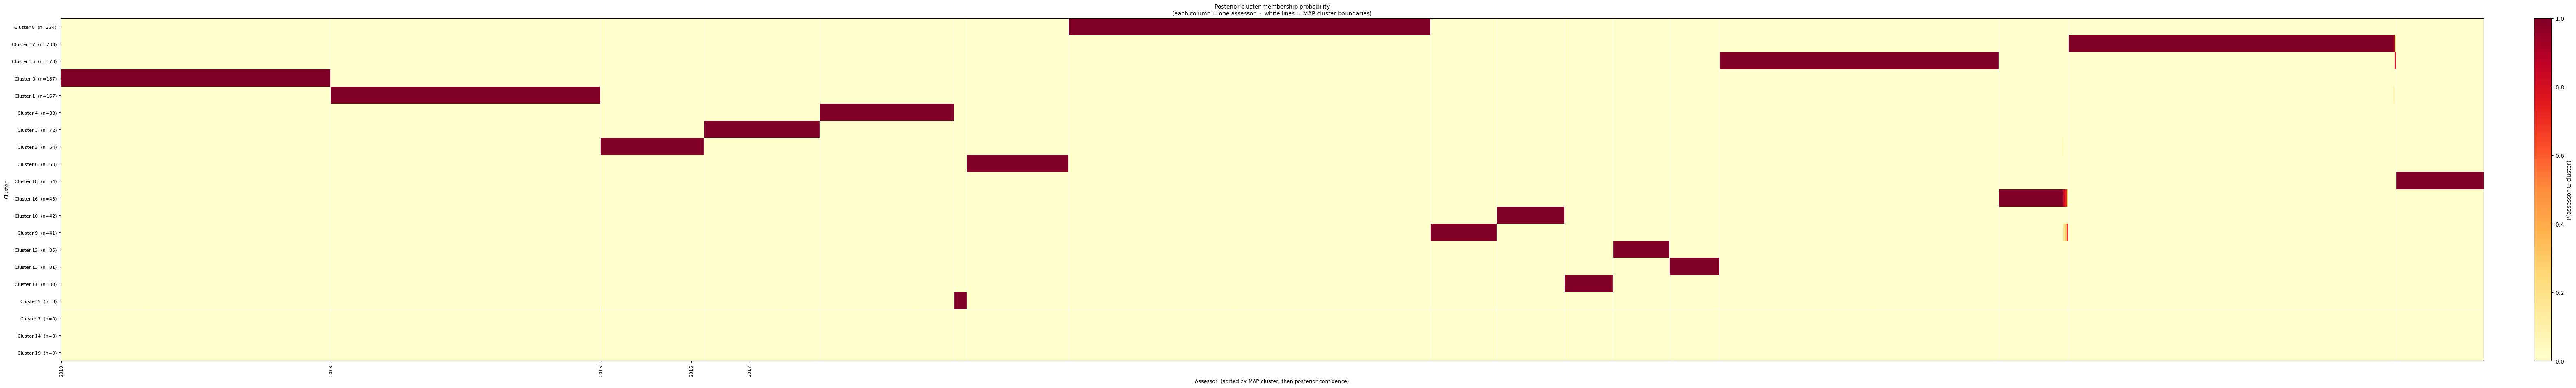

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Posterior membership matrix ───────────────────────────────────────────────
# membership[i, c] = fraction of post-burn-in samples where assessor i was in cluster c
z_arr   = np.array(samples.z_samples, dtype=np.intp)   # (T, N)
T_samp  = z_arr.shape[0]
N_assessors = len(rankings_list)

membership = np.zeros((N_assessors, C), dtype=np.float32)
for t in range(T_samp):
    membership[np.arange(N_assessors), z_arr[t]] += 1
membership /= T_samp

# ── Sort assessors by MAP cluster, then by posterior confidence desc ──────────
z_map_arr  = np.array(map_result["z"], dtype=int)
confidence = membership[np.arange(N_assessors), z_map_arr]

sort_ord   = np.lexsort((-confidence, z_map_arr))   # primary: cluster, secondary: -confidence
boundaries = np.where(np.diff(z_map_arr[sort_ord]))[0]

# ── Sort clusters rows: by cluster size (most assessors first) ───────────────
cluster_sizes = np.array([(z_map_arr == c).sum() for c in range(C)])
active_clusters = [c for c in np.argsort(-cluster_sizes) if cluster_sizes[c] > 0]
inactive        = [c for c in range(C) if cluster_sizes[c] == 0]
row_order       = active_clusters + inactive   # inactive clusters at the bottom

mem_display = membership[sort_ord][:, row_order]   # (N, C_displayed)

# ── Season tick marks along x-axis ───────────────────────────────────────────
season_x = {}
for i_sorted, i_orig in enumerate(sort_ord):
    s = season_labels[i_orig]
    if s not in season_x:
        season_x[s] = i_sorted

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(12, N_assessors * 0.04 + 4), max(5, len(active_clusters) * 0.45 + 2)))

im = ax.imshow(
    mem_display.T, vmin=0, vmax=1, cmap="YlOrRd",
    aspect="auto", interpolation="nearest",
)

# MAP cluster boundary lines (vertical)
for b in boundaries:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)

# Separator between active and inactive clusters (horizontal)
if inactive:
    ax.axhline(len(active_clusters) - 0.5, color="white", lw=1.5, linestyle="--", alpha=0.7)

# Cluster labels on y-axis
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels(
    [f"Cluster {c}  (n={cluster_sizes[c]})" for c in row_order],
    fontsize=8,
)

# Season ticks on x-axis
sorted_seasons = sorted(season_x.keys())
ax.set_xticks([season_x[s] for s in sorted_seasons])
ax.set_xticklabels(sorted_seasons, rotation=90, fontsize=8)

ax.set_xlabel("Assessor  (sorted by MAP cluster, then posterior confidence)", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)
ax.set_title(
    "Posterior cluster membership probability\n"
    "(each column = one assessor  ·  white lines = MAP cluster boundaries)",
    fontsize=10,
)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

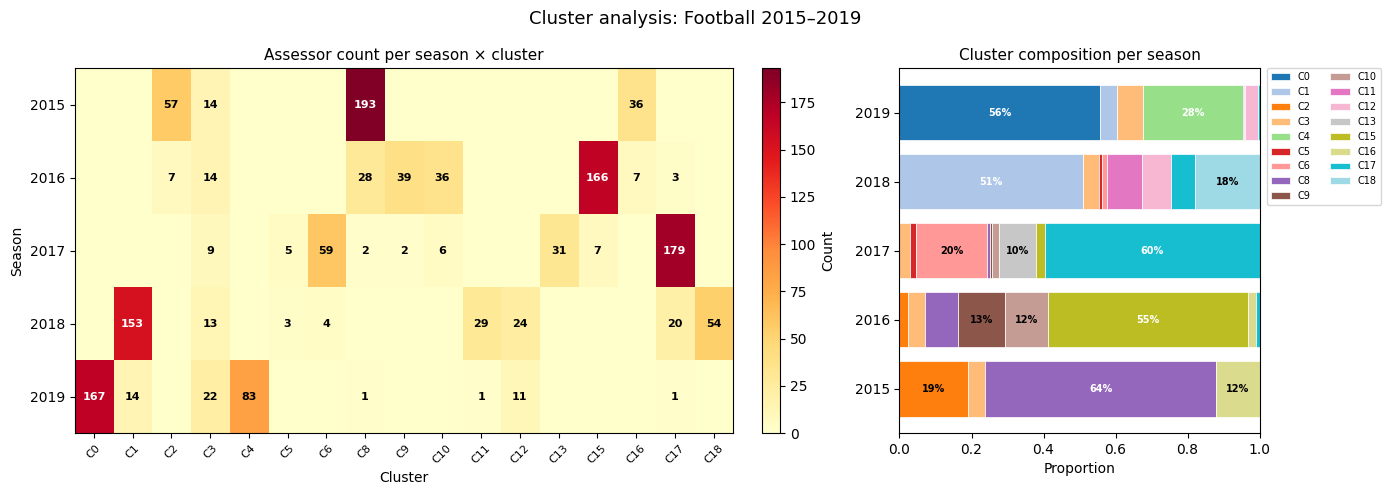

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── MAP cluster assignments ───────────────────────────────────────────────────
z_map = np.array(map_result["z"], dtype=int)

# Build summary DataFrame
assess_df = pd.DataFrame({
    "season":  season_labels,
    "cluster": z_map,
})

# Only show active clusters (non-empty)
active = sorted(assess_df["cluster"].unique())
n_active = len(active)

# ── Color map: evenly spaced by position, not cluster index ──────────────────
cmap_cl = plt.get_cmap("tab20" if n_active > 10 else "tab10", max(n_active, 1))
cl_color = {c: cmap_cl(i / max(n_active - 1, 1)) for i, c in enumerate(active)}

# ── Figure: 2 panels ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[2, 1])

# --- Panel 1: Crosstab heatmap (season × cluster) ---
ct = pd.crosstab(assess_df["season"], assess_df["cluster"])
for c in active:
    if c not in ct.columns:
        ct[c] = 0
ct = ct[active]

im = ax1.imshow(ct.values, cmap="YlOrRd", aspect="auto", interpolation="nearest")
ax1.set_xticks(range(len(active)))
ax1.set_xticklabels([f"C{c}" for c in active], fontsize=8, rotation=45)
ax1.set_yticks(range(len(ct.index)))
ax1.set_yticklabels(ct.index, fontsize=10)
ax1.set_xlabel("Cluster", fontsize=10)
ax1.set_ylabel("Season", fontsize=10)
ax1.set_title("Assessor count per season × cluster", fontsize=11)

for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        val = ct.values[i, j]
        if val > 0:
            color = "white" if val > ct.values.max() * 0.6 else "black"
            ax1.text(j, i, str(val), ha="center", va="center", fontsize=8,
                     fontweight="bold", color=color)

plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="Count")

# --- Panel 2: Stacked bar (proportion of clusters per season) ---
ct_prop = ct.div(ct.sum(axis=1), axis=0)
bottom = np.zeros(len(ct_prop))

for j, c in enumerate(active):
    vals = ct_prop[c].values
    ax2.barh(range(len(ct_prop)), vals, left=bottom, color=cl_color[c],
             label=f"C{c}", edgecolor="white", linewidth=0.5)
    for i, v in enumerate(vals):
        if v > 0.10:
            ax2.text(bottom[i] + v / 2, i, f"{v:.0%}", ha="center", va="center",
                     fontsize=7, fontweight="bold", color="white" if v > 0.25 else "black")
    bottom += vals

ax2.set_yticks(range(len(ct_prop)))
ax2.set_yticklabels(ct_prop.index, fontsize=10)
ax2.set_xlabel("Proportion", fontsize=10)
ax2.set_title("Cluster composition per season", fontsize=11)
ax2.set_xlim(0, 1)

# Compact legend outside the plot area
ax2.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0),
           ncol=1 if n_active <= 10 else 2, borderaxespad=0, frameon=True)

fig.suptitle(f"Cluster analysis: {SPORT} {min(YEARS)}–{max(YEARS)}", fontsize=13)
fig.tight_layout()
plt.show()

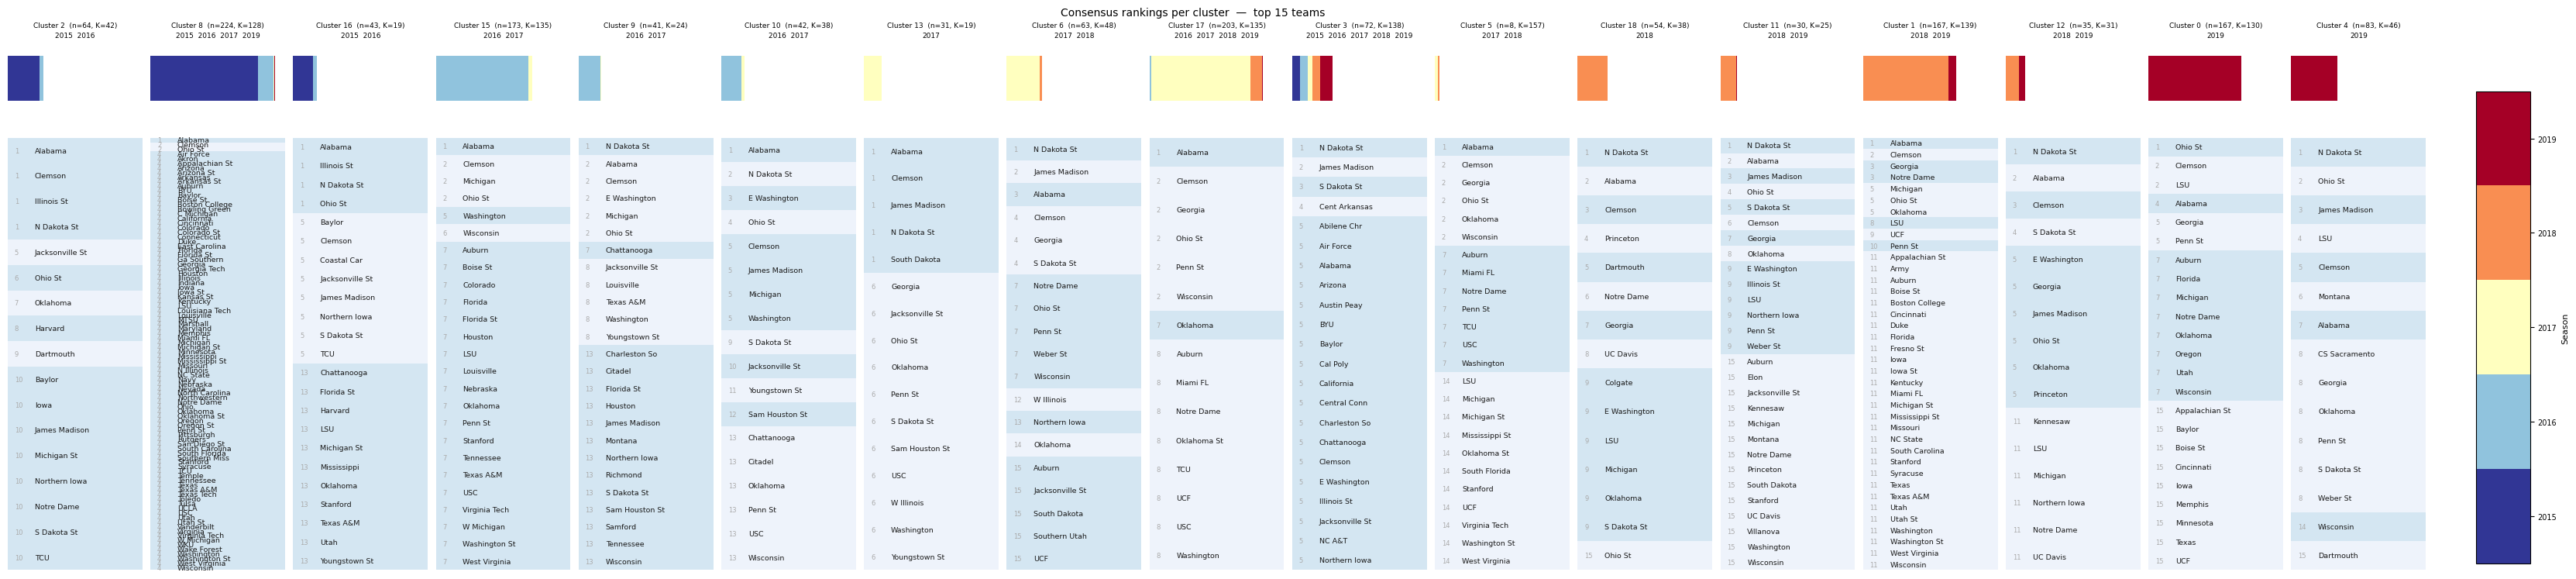

Showing 17 of 20 clusters  (filter: ≥5 voters, ≥2 blocks)
Excluded: [7, 14, 19]


In [44]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TOP_K         = 15   # top rank positions shown per cluster
MIN_VOTERS    = 5    # exclude clusters with fewer voters than this
MIN_BLOCKS    = 2    # exclude clusters whose consensus has fewer blocks than this

# ── MAP cluster assignments ───────────────────────────────────────────────────
z_map = np.array(map_result["z"], dtype=int)

# ── Season profile per cluster ────────────────────────────────────────────────
all_seasons = sorted(set(season_labels.tolist()))
n_seasons   = len(all_seasons)
s_to_i      = {s: i for i, s in enumerate(all_seasons)}

cluster_season = np.zeros((C, n_seasons), dtype=int)
for c_i, ssn in zip(z_map, season_labels):
    cluster_season[c_i, s_to_i[ssn]] += 1

# ── Filter clusters ───────────────────────────────────────────────────────────
def _n_blocks(c):
    return len(map_result["clusters"][c]["blocks"])

s_vals = np.array(all_seasons, dtype=float)
mean_s = np.array([
    (cluster_season[c] * s_vals).sum() / max(cluster_season[c].sum(), 1)
    for c in range(C)
])

cluster_order = [
    c for c in np.argsort(mean_s)
    if cluster_season[c].sum() >= MIN_VOTERS
    and _n_blocks(c) >= MIN_BLOCKS
]

if not cluster_order:
    print("No clusters passed the filters — lower MIN_VOTERS or MIN_BLOCKS.")
else:
    # ── Extract top-K teams from block structure ──────────────────────────────
    def top_k_from_blocks(blocks, k):
        rows, pos = [], 1
        for b_idx, block in enumerate(blocks):
            for item_idx in block:
                name = team_names[item_idx] if item_idx < len(team_names) else f"Team {item_idx}"
                rows.append((pos, b_idx, name))
            pos += len(block)
            if pos > k:
                break
        return [r for r in rows if r[0] <= k]

    # ── Figure ────────────────────────────────────────────────────────────────
    ncols       = len(cluster_order)
    season_cmap = plt.get_cmap("RdYlBu_r", n_seasons)
    block_bg    = ["#eef3fb", "#d4e6f2"]
    max_bar     = cluster_season[cluster_order].sum(axis=1).max() * 1.08

    fig, axes = plt.subplots(
        2, ncols,
        figsize=(ncols * 2.4, 2.8 + TOP_K * 0.37),
        gridspec_kw={"height_ratios": [1, TOP_K * 0.37]},
        squeeze=False,
    )

    for col, c in enumerate(cluster_order):
        blocks   = map_result["clusters"][c]["blocks"]
        top_rows = top_k_from_blocks(blocks, TOP_K)
        counts   = cluster_season[c]
        total    = int(counts.sum())
        n_blk    = len(blocks)

        # ── Season stacked bar ────────────────────────────────────────────────
        ax_s = axes[0, col]
        left = 0
        for s_i, cnt in enumerate(counts):
            if cnt > 0:
                ax_s.barh(0, cnt, left=left, color=season_cmap(s_i), height=0.7, linewidth=0)
                left += cnt
        ax_s.set_xlim(0, max_bar)
        ax_s.set_ylim(-0.6, 0.6)
        ax_s.axis("off")

        active_seasons = sorted(
            [all_seasons[i] for i in range(n_seasons) if counts[i] > 0]
        )
        ssn_str = "  ".join(str(s) for s in active_seasons)
        ax_s.set_title(
            f"Cluster {c}  (n={total}, K={n_blk})\n{ssn_str}",
            fontsize=6.5, pad=2, linespacing=1.5,
        )

        # ── Team ranking list ─────────────────────────────────────────────────
        ax_r = axes[1, col]
        ax_r.set_xlim(0, 1)
        ax_r.set_ylim(0, len(top_rows))
        ax_r.invert_yaxis()
        ax_r.axis("off")

        prev_block, toggle = -1, 0
        for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
            if b_idx != prev_block:
                toggle, prev_block = 1 - toggle, b_idx
            ax_r.add_patch(plt.Rectangle(
                (0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1,
            ))
            ax_r.text(0.05, row_i + 0.5, str(rank_pos),
                      fontsize=6, va="center", ha="left", color="#aaaaaa", zorder=2)
            short = name if len(name) <= 20 else name[:19] + "…"
            ax_r.text(0.20, row_i + 0.5, short,
                      fontsize=6.8, va="center", ha="left", color="#1a1a1a", zorder=2)

    # ── Season colourbar ──────────────────────────────────────────────────────
    fig.subplots_adjust(hspace=0.08, wspace=0.06, right=0.89, top=0.93)
    cax = fig.add_axes([0.906, 0.12, 0.017, 0.73])
    sm  = plt.cm.ScalarMappable(
        cmap=season_cmap,
        norm=plt.Normalize(vmin=all_seasons[0] - 0.5, vmax=all_seasons[-1] + 0.5),
    )
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_ticks(all_seasons)
    cb.ax.tick_params(labelsize=7)
    cb.set_label("Season", fontsize=8)

    fig.suptitle(
        f"Consensus rankings per cluster  —  top {TOP_K} teams",
        fontsize=10, y=0.98,
    )
    plt.show()

    print(
        f"Showing {ncols} of {C} clusters  "
        f"(filter: ≥{MIN_VOTERS} voters, ≥{MIN_BLOCKS} blocks)\n"
        f"Excluded: {[c for c in range(C) if c not in cluster_order]}"
    )


Dominant cluster per season:
  2015: Cluster 8  (193/300 = 64%)
  2016: Cluster 15  (166/300 = 55%)
  2017: Cluster 17  (179/300 = 60%)
  2018: Cluster 1  (153/300 = 51%)
  2019: Cluster 0  (167/300 = 56%)


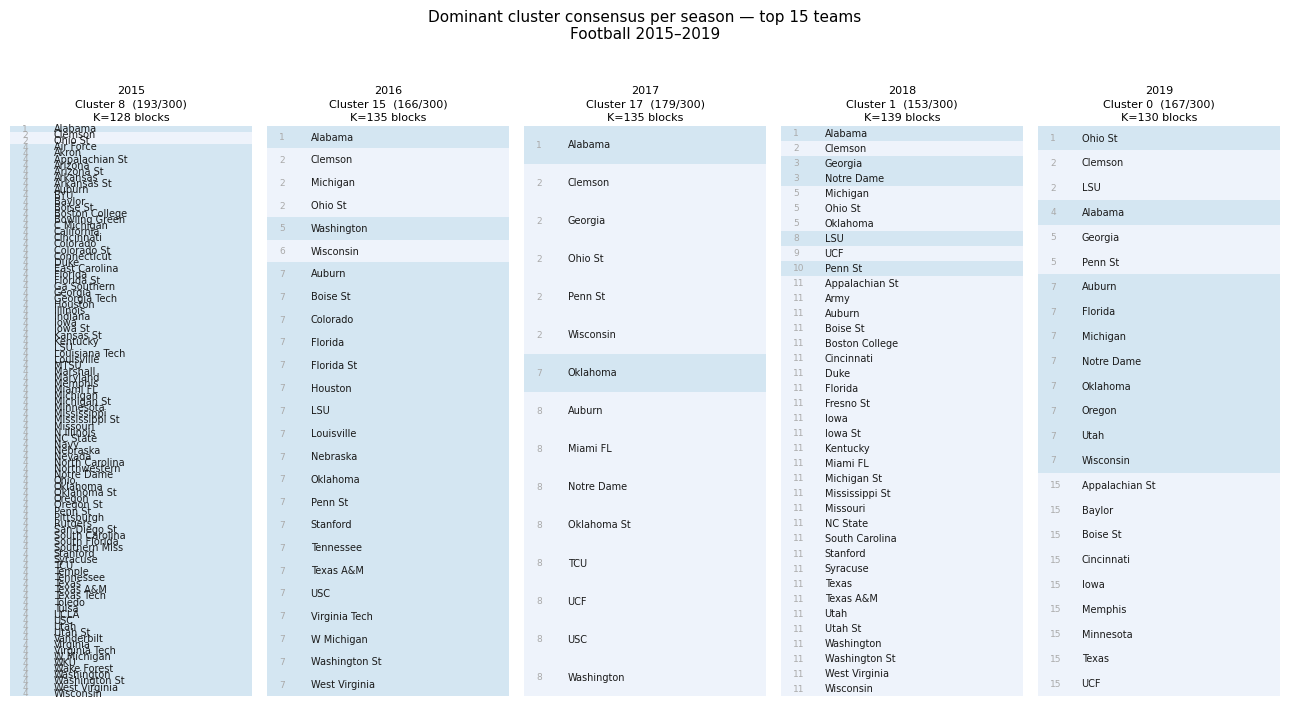

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TOP_K      = 15
z_map      = np.array(map_result["z"], dtype=int)

# ── Identify the dominant cluster per season ──────────────────────────────────
all_seasons = sorted(set(season_labels.tolist()))
dominant = {}
for season in all_seasons:
    mask = season_labels == season
    counts = np.bincount(z_map[mask], minlength=C)
    dominant[season] = int(np.argmax(counts))

season_cluster_order = [dominant[s] for s in all_seasons]
print("Dominant cluster per season:")
for s, c in zip(all_seasons, season_cluster_order):
    n_total = (season_labels == s).sum()
    n_dom   = (z_map[season_labels == s] == c).sum()
    print(f"  {s}: Cluster {c}  ({n_dom}/{n_total} = {n_dom/n_total:.0%})")

# ── Extract top-K teams from block structure ──────────────────────────────────
def top_k_from_blocks(blocks, k):
    rows, pos = [], 1
    for b_idx, block in enumerate(blocks):
        for item_idx in block:
            name = team_names[item_idx] if item_idx < len(team_names) else f"Team {item_idx}"
            rows.append((pos, b_idx, name))
        pos += len(block)
        if pos > k:
            break
    return [r for r in rows if r[0] <= k]

# ── Figure: one column per season ─────────────────────────────────────────────
ncols    = len(all_seasons)
block_bg = ["#eef3fb", "#d4e6f2"]

fig, axes = plt.subplots(
    1, ncols,
    figsize=(ncols * 2.6, TOP_K * 0.38 + 1.2),
    squeeze=False,
)

for col, (season, c) in enumerate(zip(all_seasons, season_cluster_order)):
    blocks   = map_result["clusters"][c]["blocks"]
    top_rows = top_k_from_blocks(blocks, TOP_K)
    n_blk    = len(blocks)
    n_total  = int((season_labels == season).sum())
    n_dom    = int((z_map[season_labels == season] == c).sum())

    ax = axes[0, col]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(len(top_rows), 1))
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(
        f"{season}\nCluster {c}  ({n_dom}/{n_total})\nK={n_blk} blocks",
        fontsize=8, pad=4, linespacing=1.4,
    )

    prev_block, toggle = -1, 0
    for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
        if b_idx != prev_block:
            toggle, prev_block = 1 - toggle, b_idx
        ax.add_patch(plt.Rectangle(
            (0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1,
        ))
        ax.text(0.05, row_i + 0.5, str(rank_pos),
                fontsize=6.5, va="center", ha="left", color="#aaaaaa", zorder=2)
        short = name if len(name) <= 22 else name[:21] + "…"
        ax.text(0.18, row_i + 0.5, short,
                fontsize=7, va="center", ha="left", color="#1a1a1a", zorder=2)

fig.suptitle(
    f"Dominant cluster consensus per season — top {TOP_K} teams\n"
    f"{SPORT} {min(all_seasons)}–{max(all_seasons)}",
    fontsize=11, y=1.02,
)
fig.subplots_adjust(wspace=0.08)
plt.tight_layout()
plt.show()

---
# Baseball — Multi-Season Analysis
Same pipeline as Football, using Baseball seasons from PrefLib dataset 00055.

## Download & Prepare Multi-Season Data — Baseball

In [7]:
SPORT_BB = "Baseball"
YEARS_BB = [2015, 2016, 2017, 2018, 2019]  # 5 recent seasons
VOTERS_PER_SEASON_BB = 300

rng_bb = np.random.default_rng(42)
selected_bb = [d for d in all_datasets if d.sport == SPORT_BB and d.year in YEARS_BB]
print(f"Selected {len(selected_bb)} seasons: {[d.year for d in selected_bb]}")

# Find teams common to ALL selected seasons
common_teams_bb = None
for ds in selected_bb:
    names = set(ds.teams.values())
    common_teams_bb = names if common_teams_bb is None else common_teams_bb & names
common_teams_bb = sorted(common_teams_bb)
print(f"Common teams across seasons: {len(common_teams_bb)}")

# Build wide DataFrames per season, restrict to common teams, subsample voters
frames_bb = []
season_labels_bb = []
for ds in selected_bb:
    w = ds.to_wide_dataframe()
    w = w[common_teams_bb]
    n = min(VOTERS_PER_SEASON_BB, len(w))
    idx = rng_bb.choice(len(w), size=n, replace=False)
    w = w.iloc[idx].reset_index(drop=True)
    frames_bb.append(w)
    season_labels_bb.extend([ds.year] * n)

wide_bb = pd.concat(frames_bb, ignore_index=True)
team_names_bb = list(wide_bb.columns)
season_labels_bb = np.array(season_labels_bb)

# Fill unranked teams with last rank
matrix_bb = wide_bb.values.copy()
for i in range(matrix_bb.shape[0]):
    ranked_count = np.sum(~np.isnan(matrix_bb[i]))
    matrix_bb[i, np.isnan(matrix_bb[i])] = ranked_count + 1

matrix_bb = matrix_bb.astype(int)
print(f"Rank matrix shape: {matrix_bb.shape}  (voters x teams)")
print(f"Teams: {len(team_names_bb)}")
print(f"Voters per season: {dict(zip(*np.unique(season_labels_bb, return_counts=True)))}")

Selected 5 seasons: [2015, 2016, 2017, 2018, 2019]
Common teams across seasons: 297
Rank matrix shape: (1281, 297)  (voters x teams)
Teams: 297
Voters per season: {np.int64(2015): np.int64(249), np.int64(2016): np.int64(266), np.int64(2017): np.int64(233), np.int64(2018): np.int64(254), np.int64(2019): np.int64(279)}


## Parameters

In [10]:
gamma_bb = 1
delta_bb = 0.5
C_bb = 20

rankings_list_bb = [list(np.argsort(row)) for row in matrix_bb]

## Spectral Clustering Initialization — Baseball

In [ ]:

clusters_bb, z_init_bb = init_spectral_with_z(
    rankings=rankings_list_bb,
    n_clusters=C_bb,
    py_sampling=False,
    gamma=gamma_bb,
    delta=delta_bb,
    seed=123,
    affinity="rbf",
)

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (4) found smaller than n_clusters (20). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [61]:
print("Cluster sizes:")
print(pd.Series(z_init_bb).value_counts().sort_index())
print(f"\nAdjusted Rand Index (z_init vs season): {adjusted_rand_score(season_labels_bb, z_init_bb):.3f}")
print("\nCrosstab (season x cluster):")
print(pd.crosstab(season_labels_bb, z_init_bb, rownames=["season"], colnames=["cluster"]))

Cluster sizes:
1       1
2       1
3       1
4    1278
Name: count, dtype: int64

Adjusted Rand Index (z_init vs season): 0.000

Crosstab (season x cluster):
cluster  1  2  3    4
season               
2015     0  0  0  249
2016     1  0  0  265
2017     0  1  1  231
2018     0  0  0  254
2019     0  0  0  279


## Run MCMC — Baseball

In [11]:
rankings_list_bb = [list(np.argsort(row)) for row in matrix_bb]
n_assessors_bb = len(rankings_list_bb)
init_mu_bb = [n_assessors_bb / C_bb for _ in range(C_bb)]
p_hat_bb = 0.50

model_bb = MixtureRankingModel(
    rankings=rankings_list_bb,
    #init_clusters=clusters_bb,
    n_clusters=C_bb,
    init_mu=init_mu_bb,
    seed=42,
    verbose=True,
    init_theta=1.0,
)

final_state_bb, samples_bb = model_bb.run_mcmc(
    n_iter=15000,
    burn_in=10000,
    thin=1,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    gamma=gamma_bb,
    delta=delta_bb,
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    use_annealing=True,
    temp_min=0.25,
    temp_max=1.0,
    tie_penalty=p_hat_bb,
)

if samples_bb is not None:
    summaries_bb = model_bb.estimate_map(samples_bb, ci=0.95)
    print("MAP-like summaries:", summaries_bb)

C:\Users\jonanord\AppData\Local\Temp\ipykernel_25736\3169855145.py:6: UserWarning: init_clusters not provided. For best results supply them via init_spectral_with_z(rankings, n_clusters=C, seed=...). Falling back to trivial initialization.
  model_bb = MixtureRankingModel(


[Model] Initialized: N=1281 assessors, n=297 items, C=20 clusters, n_pairs=43,956
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    1281×43,956  (214.8 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 149 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 149 blocks, theta=1.000, gamma=1.000, delta=0.50

In [12]:
model_bb.print_acceptance_summary()


MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2476/4999
Log-posterior improvement rate: 49.53%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 0 accepts, acceptance_rate=0.00%
  Cluster 1: 2545 accepts, acceptance_rate=50.90%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 0 accepts, acceptance_rate=0.00%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 2999 accepts, acceptance_rate=59.98%
  Cluster 7: 219 accepts, acceptance_rate=4.38%
  Cluster 8: 0 accepts, acceptance_rate=0.00%
  Cluster 9: 0 accepts, acceptance_rate=0.00%
  Cluster 10: 0 accepts, acceptance_rate=0.00%
  Cluster 11: 0 accepts, acceptance_rate=0.00%
  Cluster 12: 0 accepts, acceptance_rate=0.00%
  Cluster 13: 0 accepts, acceptance_rate=0.00%
  Cluster 14: 0 accepts, acceptance_rate=0.00%
  Cluster 15: 0 accepts, acceptance_rate=0.00%
  Cluster 16: 0 accepts, acceptance_rate=0.00%
  Cluster 17: 0 accepts, acceptance_rate=0.00%


In [13]:
map_result_bb = model_bb.find_map(samples_bb, refine=True, verbose=True)

for c, cl in enumerate(map_result_bb["clusters"]):
    print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=4080 with logp=-1395509.7509
  Cluster 1: 92 moves in 4 sweeps, K=80 blocks
  Cluster 6: 103 moves in 5 sweeps, K=211 blocks
  Cluster 7: 4 moves in 2 sweeps, K=295 blocks
[MAP] logp: -1395509.7509 → -1395275.0455 (Δ=+234.7053)
Cluster 0: [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9], [10, 11], [12, 13], [14, 15], [107], [16, 17], [18, 19], [20, 21], [22, 23], [24, 25], [26, 27], [28, 29], [30, 31], [32, 33], [34, 35], [36, 37], [38, 39], [40, 41], [42, 43], [44, 45], [46, 47], [48, 49], [50, 51], [52, 53], [54, 55], [56, 57], [58, 59], [60, 61], [62, 63], [64, 65], [66, 67], [68, 69], [70, 71], [72, 73], [74, 75], [76, 77], [78, 79], [80, 81], [82, 83], [84, 85], [86, 87], [88, 89], [90, 91], [92, 93], [94, 95], [96, 97], [98, 99], [100, 101], [102, 103], [104, 105], [106], [108, 109], [110, 111], [112, 113], [114, 115], [116, 117], [118, 119], [120, 121], [122, 123], [124, 125], [126, 127], [128, 129], [130, 131], [132, 133], [134, 135], [136, 137], [138, 139], [140,

In [14]:
import json, pickle
from datetime import datetime

RUNS_DIR_BB = SAVE_DIR / "runs"
run_name_bb = f"sp_{SPORT_BB.lower()}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir_bb  = RUNS_DIR_BB / run_name_bb
run_dir_bb.mkdir(parents=True, exist_ok=True)

mcmc_params_bb = dict(
    n_assessors=len(rankings_list_bb), n_items=len(team_names_bb),
    sport=SPORT_BB, years=YEARS_BB, voters_per_season=VOTERS_PER_SEASON_BB,
    C=C_bb, gamma=gamma_bb, delta=delta_bb, p_hat=p_hat_bb,
    n_iter=15000, burn_in=10000, thin=1, n_item_moves_per_cluster=1,
    a_theta=4, b_theta=1, theta_jump=10,
    use_annealing=True, temp_min=0.25, temp_max=1.0,
    run_name=run_name_bb, saved_at=datetime.now().isoformat(),
)
with open(run_dir_bb / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params_bb, f, indent=2)

map_ser_bb = {
    "best_t": int(map_result_bb["best_t"]),
    "logp_chain": float(map_result_bb["logp_chain"]),
    "logp_refined": float(map_result_bb.get("logp_refined", map_result_bb["logp_chain"])),
    "z": [int(x) for x in map_result_bb["z"]],
    "clusters": [{"blocks": cl["blocks"], "theta": float(cl["theta"])} for cl in map_result_bb["clusters"]],
}
with open(run_dir_bb / "map_result.json", "w") as f:
    json.dump(map_ser_bb, f, indent=2)

pd.DataFrame({"assessor_idx": range(len(season_labels_bb)), "season": season_labels_bb}).to_csv(run_dir_bb / "assessors.csv", index=False)
pd.DataFrame({"team_idx": range(len(team_names_bb)), "team_name": team_names_bb}).to_csv(run_dir_bb / "teams.csv", index=False)

with open(run_dir_bb / "samples.pkl", "wb") as f:
    pickle.dump(samples_bb, f)
with open(run_dir_bb / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_bb, f)

print(f"Run saved to: {run_dir_bb}")
for p in sorted(run_dir_bb.iterdir()):
    print(f"  {p.name:<25}  {p.stat().st_size / 1024:>8.1f} KB")

Run saved to: sport_power\runs\sp_baseball_20260408_144644
  assessors.csv                  12.7 KB
  final_state.pkl                35.7 KB
  map_result.json               170.7 KB
  mcmc_params.json                0.5 KB
  samples.pkl                174584.8 KB
  teams.csv                       4.3 KB


## Visualizations — Baseball

In [15]:
z_map_bb = np.array(map_result_bb["z"], dtype=int)
print("Cluster sizes:")
print(pd.Series(z_map_bb).value_counts().sort_index())
print(f"\nAdjusted Rand Index (z_map vs season): {adjusted_rand_score(season_labels_bb, z_map_bb):.3f}")
print("\nCrosstab (season x cluster):")
print(pd.crosstab(season_labels_bb, z_map_bb, rownames=["season"], colnames=["cluster"]))

Cluster sizes:
1    120
6    618
7    543
Name: count, dtype: int64

Adjusted Rand Index (z_map vs season): 0.072

Crosstab (season x cluster):
cluster    1    6    7
season                
2015       0  131  118
2016       0  148  118
2017     118   12  103
2018       2  150  102
2019       0  177  102


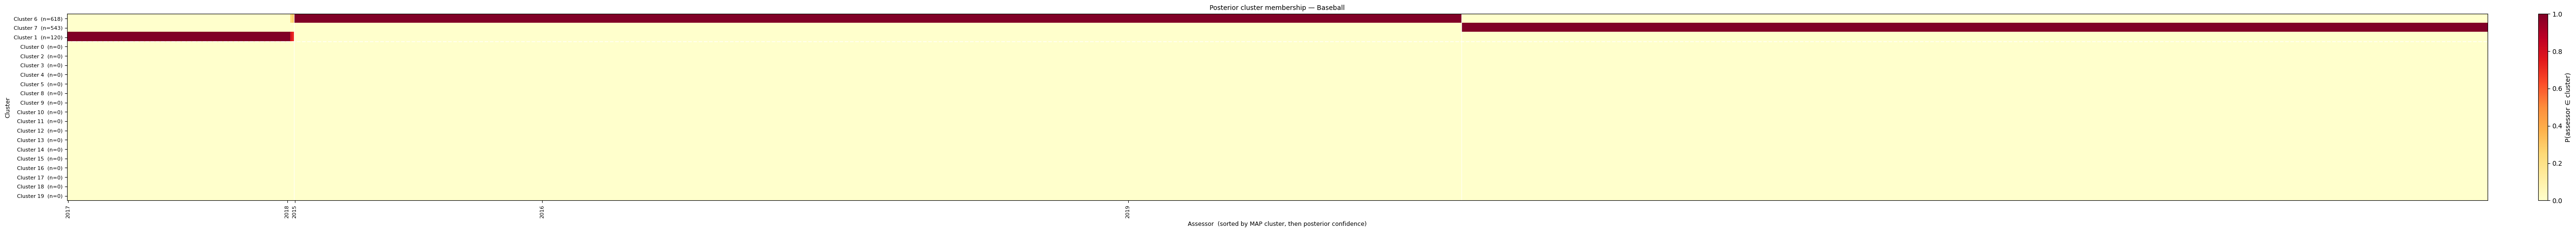

In [18]:
# ── Posterior membership heatmap — Baseball ───────────────────────────────────
z_arr_bb   = np.array(samples_bb.z_samples, dtype=np.intp)
T_samp_bb  = z_arr_bb.shape[0]
N_bb = len(rankings_list_bb)

membership_bb = np.zeros((N_bb, C_bb), dtype=np.float32)
for t in range(T_samp_bb):
    membership_bb[np.arange(N_bb), z_arr_bb[t]] += 1
membership_bb /= T_samp_bb

z_map_arr_bb  = np.array(map_result_bb["z"], dtype=int)
confidence_bb = membership_bb[np.arange(N_bb), z_map_arr_bb]

sort_ord_bb   = np.lexsort((-confidence_bb, z_map_arr_bb))
boundaries_bb = np.where(np.diff(z_map_arr_bb[sort_ord_bb]))[0]

cluster_sizes_bb = np.array([(z_map_arr_bb == c).sum() for c in range(C_bb)])
active_bb = [c for c in np.argsort(-cluster_sizes_bb) if cluster_sizes_bb[c] > 0]
inactive_bb = [c for c in range(C_bb) if cluster_sizes_bb[c] == 0]
row_order_bb = active_bb + inactive_bb

mem_display_bb = membership_bb[sort_ord_bb][:, row_order_bb]

season_x_bb = {}
for i_s, i_o in enumerate(sort_ord_bb):
    s = season_labels_bb[i_o]
    if s not in season_x_bb:
        season_x_bb[s] = i_s

fig, ax = plt.subplots(figsize=(max(12, N_bb * 0.04 + 4), max(5, len(active_bb) * 0.45 + 2)))
im = ax.imshow(mem_display_bb.T, vmin=0, vmax=1, cmap="YlOrRd", aspect="auto", interpolation="nearest")
for b in boundaries_bb:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)
if inactive_bb:
    ax.axhline(len(active_bb) - 0.5, color="white", lw=1.5, linestyle="--", alpha=0.7)
ax.set_yticks(range(len(row_order_bb)))
ax.set_yticklabels([f"Cluster {c}  (n={cluster_sizes_bb[c]})" for c in row_order_bb], fontsize=8)
sorted_seasons_bb = sorted(season_x_bb.keys())
ax.set_xticks([season_x_bb[s] for s in sorted_seasons_bb])
ax.set_xticklabels(sorted_seasons_bb, rotation=90, fontsize=8)
ax.set_xlabel("Assessor  (sorted by MAP cluster, then posterior confidence)", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)
ax.set_title("Posterior cluster membership — Baseball", fontsize=10)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

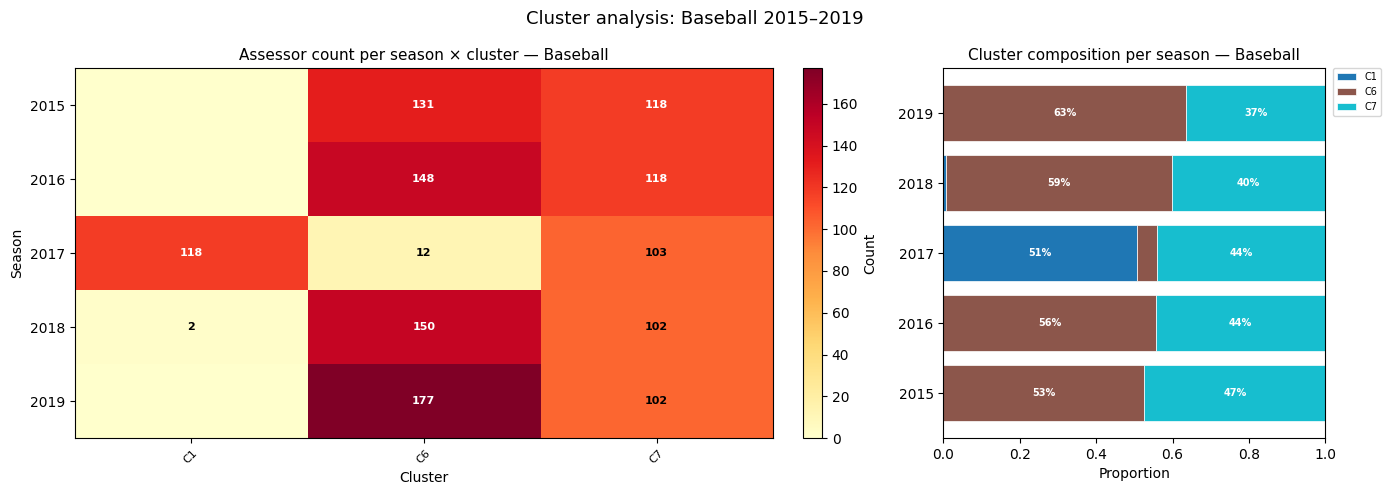

In [19]:
# ── Cluster analysis 2-panel — Baseball ───────────────────────────────────────
z_map_bb = np.array(map_result_bb["z"], dtype=int)
assess_df_bb = pd.DataFrame({"season": season_labels_bb, "cluster": z_map_bb})
active_bb2 = sorted(assess_df_bb["cluster"].unique())
n_active_bb = len(active_bb2)

cmap_bb = plt.get_cmap("tab20" if n_active_bb > 10 else "tab10", max(n_active_bb, 1))
cl_color_bb = {c: cmap_bb(i / max(n_active_bb - 1, 1)) for i, c in enumerate(active_bb2)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[2, 1])
ct_bb = pd.crosstab(assess_df_bb["season"], assess_df_bb["cluster"])
for c in active_bb2:
    if c not in ct_bb.columns:
        ct_bb[c] = 0
ct_bb = ct_bb[active_bb2]

im = ax1.imshow(ct_bb.values, cmap="YlOrRd", aspect="auto", interpolation="nearest")
ax1.set_xticks(range(len(active_bb2)))
ax1.set_xticklabels([f"C{c}" for c in active_bb2], fontsize=8, rotation=45)
ax1.set_yticks(range(len(ct_bb.index)))
ax1.set_yticklabels(ct_bb.index, fontsize=10)
ax1.set_xlabel("Cluster"); ax1.set_ylabel("Season")
ax1.set_title("Assessor count per season × cluster — Baseball", fontsize=11)
for i in range(ct_bb.shape[0]):
    for j in range(ct_bb.shape[1]):
        val = ct_bb.values[i, j]
        if val > 0:
            color = "white" if val > ct_bb.values.max() * 0.6 else "black"
            ax1.text(j, i, str(val), ha="center", va="center", fontsize=8, fontweight="bold", color=color)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="Count")

ct_prop_bb = ct_bb.div(ct_bb.sum(axis=1), axis=0)
bottom_bb = np.zeros(len(ct_prop_bb))
for j, c in enumerate(active_bb2):
    vals = ct_prop_bb[c].values
    ax2.barh(range(len(ct_prop_bb)), vals, left=bottom_bb, color=cl_color_bb[c], label=f"C{c}", edgecolor="white", linewidth=0.5)
    for i, v in enumerate(vals):
        if v > 0.10:
            ax2.text(bottom_bb[i] + v / 2, i, f"{v:.0%}", ha="center", va="center", fontsize=7, fontweight="bold", color="white" if v > 0.25 else "black")
    bottom_bb += vals
ax2.set_yticks(range(len(ct_prop_bb)))
ax2.set_yticklabels(ct_prop_bb.index, fontsize=10)
ax2.set_xlabel("Proportion"); ax2.set_title("Cluster composition per season — Baseball", fontsize=11)
ax2.set_xlim(0, 1)
ax2.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1 if n_active_bb <= 10 else 2, borderaxespad=0, frameon=True)
fig.suptitle(f"Cluster analysis: {SPORT_BB} {min(YEARS_BB)}–{max(YEARS_BB)}", fontsize=13)
fig.tight_layout()
plt.show()

Dominant cluster per season:
  2015: Cluster 6  (131/249 = 53%)
  2016: Cluster 6  (148/266 = 56%)
  2017: Cluster 1  (118/233 = 51%)
  2018: Cluster 6  (150/254 = 59%)
  2019: Cluster 6  (177/279 = 63%)


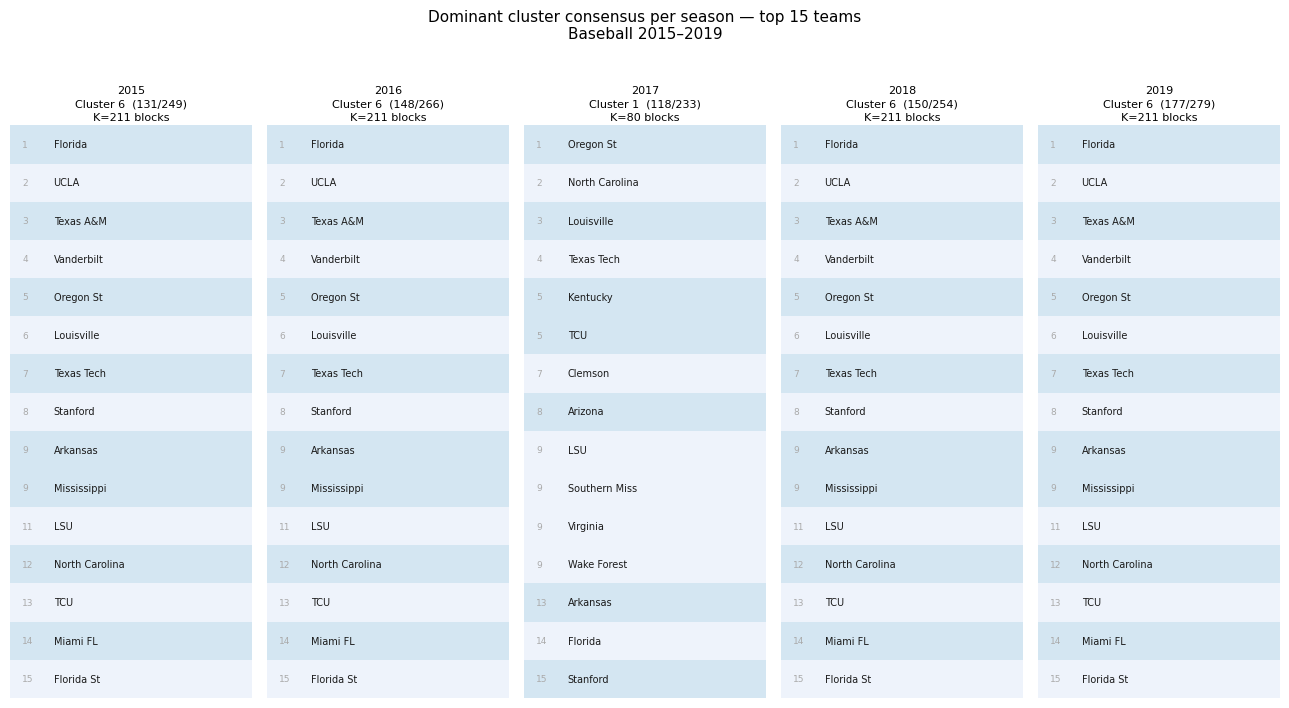

In [20]:
# ── Dominant cluster consensus per season — Baseball ──────────────────────────
TOP_K_BB = 15
z_map_bb = np.array(map_result_bb["z"], dtype=int)
all_seasons_bb = sorted(set(season_labels_bb.tolist()))

dominant_bb = {}
for season in all_seasons_bb:
    mask = season_labels_bb == season
    counts = np.bincount(z_map_bb[mask], minlength=C_bb)
    dominant_bb[season] = int(np.argmax(counts))

season_cluster_order_bb = [dominant_bb[s] for s in all_seasons_bb]
print("Dominant cluster per season:")
for s, c in zip(all_seasons_bb, season_cluster_order_bb):
    n_total = (season_labels_bb == s).sum()
    n_dom   = (z_map_bb[season_labels_bb == s] == c).sum()
    print(f"  {s}: Cluster {c}  ({n_dom}/{n_total} = {n_dom/n_total:.0%})")

def top_k_from_blocks_bb(blocks, k):
    rows, pos = [], 1
    for b_idx, block in enumerate(blocks):
        for item_idx in block:
            name = team_names_bb[item_idx] if item_idx < len(team_names_bb) else f"Team {item_idx}"
            rows.append((pos, b_idx, name))
        pos += len(block)
        if pos > k:
            break
    return [r for r in rows if r[0] <= k]

ncols_bb = len(all_seasons_bb)
block_bg = ["#eef3fb", "#d4e6f2"]
fig, axes = plt.subplots(1, ncols_bb, figsize=(ncols_bb * 2.6, TOP_K_BB * 0.38 + 1.2), squeeze=False)

for col, (season, c) in enumerate(zip(all_seasons_bb, season_cluster_order_bb)):
    blocks = map_result_bb["clusters"][c]["blocks"]
    top_rows = top_k_from_blocks_bb(blocks, TOP_K_BB)
    n_blk = len(blocks)
    n_total = int((season_labels_bb == season).sum())
    n_dom = int((z_map_bb[season_labels_bb == season] == c).sum())

    ax = axes[0, col]
    ax.set_xlim(0, 1); ax.set_ylim(0, max(len(top_rows), 1)); ax.invert_yaxis(); ax.axis("off")
    ax.set_title(f"{season}\nCluster {c}  ({n_dom}/{n_total})\nK={n_blk} blocks", fontsize=8, pad=4, linespacing=1.4)

    prev_block, toggle = -1, 0
    for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
        if b_idx != prev_block:
            toggle, prev_block = 1 - toggle, b_idx
        ax.add_patch(plt.Rectangle((0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1))
        ax.text(0.05, row_i + 0.5, str(rank_pos), fontsize=6.5, va="center", ha="left", color="#aaaaaa", zorder=2)
        short = name if len(name) <= 22 else name[:21] + "…"
        ax.text(0.18, row_i + 0.5, short, fontsize=7, va="center", ha="left", color="#1a1a1a", zorder=2)

fig.suptitle(f"Dominant cluster consensus per season — top {TOP_K_BB} teams\n{SPORT_BB} {min(all_seasons_bb)}–{max(all_seasons_bb)}", fontsize=11, y=1.02)
fig.subplots_adjust(wspace=0.08)
plt.tight_layout()
plt.show()

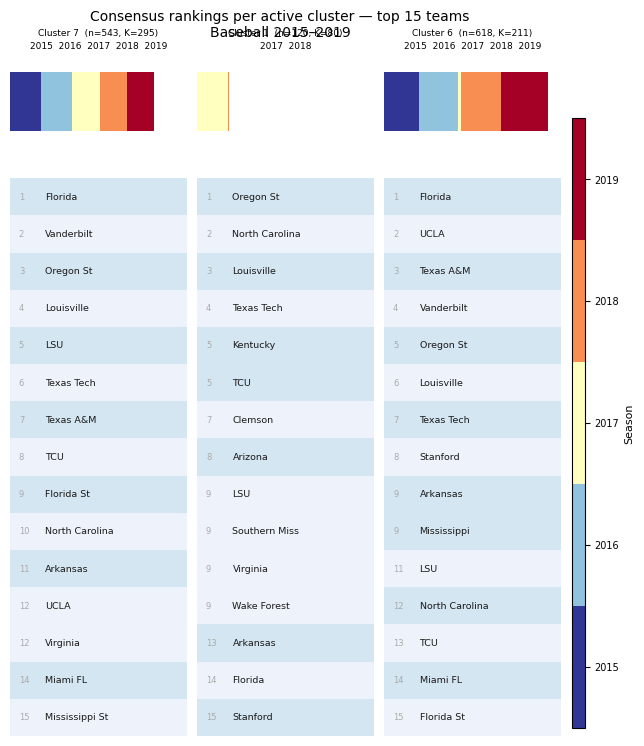

Showing 3 active clusters out of 20 total


In [21]:
# ── Consensus rankings per active cluster — Baseball ──────────────────────────
TOP_K_BB = 15

z_map_bb = np.array(map_result_bb["z"], dtype=int)
all_seasons_bb = sorted(set(season_labels_bb.tolist()))
n_seasons_bb = len(all_seasons_bb)
s_to_i_bb = {s: i for i, s in enumerate(all_seasons_bb)}

cluster_season_bb = np.zeros((C_bb, n_seasons_bb), dtype=int)
for c_i, ssn in zip(z_map_bb, season_labels_bb):
    cluster_season_bb[c_i, s_to_i_bb[ssn]] += 1

# ── Filter to active clusters (non-empty), ordered by mean season ────────────
s_vals_bb = np.array(all_seasons_bb, dtype=float)
mean_s_bb = np.array([
    (cluster_season_bb[c] * s_vals_bb).sum() / max(cluster_season_bb[c].sum(), 1)
    for c in range(C_bb)
])
cluster_order_bb = [c for c in np.argsort(mean_s_bb) if cluster_season_bb[c].sum() > 0]

def top_k_from_blocks_bb(blocks, k):
    rows, pos = [], 1
    for b_idx, block in enumerate(blocks):
        for item_idx in block:
            name = team_names_bb[item_idx] if item_idx < len(team_names_bb) else f"Team {item_idx}"
            rows.append((pos, b_idx, name))
        pos += len(block)
        if pos > k:
            break
    return [r for r in rows if r[0] <= k]

# ── Figure ────────────────────────────────────────────────────────────────────
ncols_bb = len(cluster_order_bb)
season_cmap_bb = plt.get_cmap("RdYlBu_r", n_seasons_bb)
block_bg = ["#eef3fb", "#d4e6f2"]
max_bar_bb = cluster_season_bb[cluster_order_bb].sum(axis=1).max() * 1.08

fig, axes = plt.subplots(
    2, ncols_bb,
    figsize=(ncols_bb * 2.4, 2.8 + TOP_K_BB * 0.37),
    gridspec_kw={"height_ratios": [1, TOP_K_BB * 0.37]},
    squeeze=False,
)

for col, c in enumerate(cluster_order_bb):
    blocks = map_result_bb["clusters"][c]["blocks"]
    top_rows = top_k_from_blocks_bb(blocks, TOP_K_BB)
    counts = cluster_season_bb[c]
    total = int(counts.sum())
    n_blk = len(blocks)

    # ── Season stacked bar ────────────────────────────────────────────────
    ax_s = axes[0, col]
    left = 0
    for s_i, cnt in enumerate(counts):
        if cnt > 0:
            ax_s.barh(0, cnt, left=left, color=season_cmap_bb(s_i), height=0.7, linewidth=0)
            left += cnt
    ax_s.set_xlim(0, max_bar_bb)
    ax_s.set_ylim(-0.6, 0.6)
    ax_s.axis("off")

    active_seasons_bb = sorted(
        [all_seasons_bb[i] for i in range(n_seasons_bb) if counts[i] > 0]
    )
    ssn_str = "  ".join(str(s) for s in active_seasons_bb)
    ax_s.set_title(
        f"Cluster {c}  (n={total}, K={n_blk})\n{ssn_str}",
        fontsize=6.5, pad=2, linespacing=1.5,
    )

    # ── Team ranking list ─────────────────────────────────────────────────
    ax_r = axes[1, col]
    ax_r.set_xlim(0, 1)
    ax_r.set_ylim(0, max(len(top_rows), 1))
    ax_r.invert_yaxis()
    ax_r.axis("off")

    prev_block, toggle = -1, 0
    for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
        if b_idx != prev_block:
            toggle, prev_block = 1 - toggle, b_idx
        ax_r.add_patch(plt.Rectangle(
            (0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1,
        ))
        ax_r.text(0.05, row_i + 0.5, str(rank_pos),
                  fontsize=6, va="center", ha="left", color="#aaaaaa", zorder=2)
        short = name if len(name) <= 20 else name[:19] + "…"
        ax_r.text(0.20, row_i + 0.5, short,
                  fontsize=6.8, va="center", ha="left", color="#1a1a1a", zorder=2)

# ── Season colourbar ──────────────────────────────────────────────────────
fig.subplots_adjust(hspace=0.08, wspace=0.06, right=0.89, top=0.93)
cax = fig.add_axes([0.906, 0.12, 0.017, 0.73])
sm = plt.cm.ScalarMappable(
    cmap=season_cmap_bb,
    norm=plt.Normalize(vmin=all_seasons_bb[0] - 0.5, vmax=all_seasons_bb[-1] + 0.5),
)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_ticks(all_seasons_bb)
cb.ax.tick_params(labelsize=7)
cb.set_label("Season", fontsize=8)

fig.suptitle(
    f"Consensus rankings per active cluster — top {TOP_K_BB} teams\n{SPORT_BB} {min(all_seasons_bb)}–{max(all_seasons_bb)}",
    fontsize=10, y=0.98,
)
plt.show()

print(f"Showing {ncols_bb} active clusters out of {C_bb} total")

---
# Basketball — Multi-Season Analysis
Same pipeline as Football, using Basketball seasons from PrefLib dataset 00055.

## Download & Prepare Multi-Season Data — Basketball

In [46]:
SPORT_BK = "Basketball"
YEARS_BK = [2015, 2016, 2017, 2018, 2019]  # 5 recent seasons
VOTERS_PER_SEASON_BK = 300

rng_bk = np.random.default_rng(42)
selected_bk = [d for d in all_datasets if d.sport == SPORT_BK and d.year in YEARS_BK]
print(f"Selected {len(selected_bk)} seasons: {[d.year for d in selected_bk]}")

common_teams_bk = None
for ds in selected_bk:
    names = set(ds.teams.values())
    common_teams_bk = names if common_teams_bk is None else common_teams_bk & names
common_teams_bk = sorted(common_teams_bk)
print(f"Common teams across seasons: {len(common_teams_bk)}")

frames_bk = []
season_labels_bk = []
for ds in selected_bk:
    w = ds.to_wide_dataframe()
    w = w[common_teams_bk]
    n = min(VOTERS_PER_SEASON_BK, len(w))
    idx = rng_bk.choice(len(w), size=n, replace=False)
    w = w.iloc[idx].reset_index(drop=True)
    frames_bk.append(w)
    season_labels_bk.extend([ds.year] * n)

wide_bk = pd.concat(frames_bk, ignore_index=True)
team_names_bk = list(wide_bk.columns)
season_labels_bk = np.array(season_labels_bk)

matrix_bk = wide_bk.values.copy()
for i in range(matrix_bk.shape[0]):
    ranked_count = np.sum(~np.isnan(matrix_bk[i]))
    matrix_bk[i, np.isnan(matrix_bk[i])] = ranked_count + 1

matrix_bk = matrix_bk.astype(int)
print(f"Rank matrix shape: {matrix_bk.shape}  (voters x teams)")
print(f"Teams: {len(team_names_bk)}")
print(f"Voters per season: {dict(zip(*np.unique(season_labels_bk, return_counts=True)))}")

Selected 5 seasons: [2015, 2016, 2017, 2018, 2019]
Common teams across seasons: 329
Rank matrix shape: (1500, 329)  (voters x teams)
Teams: 329
Voters per season: {np.int64(2015): np.int64(300), np.int64(2016): np.int64(300), np.int64(2017): np.int64(300), np.int64(2018): np.int64(300), np.int64(2019): np.int64(300)}


## Spectral Clustering Initialization — Basketball

In [48]:
gamma_bk = 1
delta_bk = 0.5
C_bk = 20

rankings_list_bk = [list(np.argsort(row)) for row in matrix_bk]

clusters_bk, z_init_bk = init_spectral_with_z(
    rankings=rankings_list_bk,
    n_clusters=C_bk,
    py_sampling=False,
    gamma=gamma_bk,
    delta=delta_bk,
    seed=123,
    affinity="rbf",
)

c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (20). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [49]:
print("Cluster sizes:")
print(pd.Series(z_init_bk).value_counts().sort_index())
print(f"\nAdjusted Rand Index (z_init vs season): {adjusted_rand_score(season_labels_bk, z_init_bk):.3f}")
print("\nCrosstab (season x cluster):")
print(pd.crosstab(season_labels_bk, z_init_bk, rownames=["season"], colnames=["cluster"]))

Cluster sizes:
0    1496
1       2
2       2
Name: count, dtype: int64

Adjusted Rand Index (z_init vs season): 0.000

Crosstab (season x cluster):
cluster    0  1  2
season            
2015     298  2  0
2016     300  0  0
2017     300  0  0
2018     298  0  2
2019     300  0  0


## Run MCMC — Basketball

In [51]:
n_assessors_bk = len(rankings_list_bk)
init_mu_bk = [n_assessors_bk / C_bk for _ in range(C_bk)]
p_hat_bk = 0.50

model_bk = MixtureRankingModel(
    rankings=rankings_list_bk,
    #init_clusters=clusters_bk,
    n_clusters = C_bk,
    n_items = len(team_names_bk),
    init_mu=init_mu_bk,
    seed=42,
    verbose=True,
    init_theta=1.0,
)

final_state_bk, samples_bk = model_bk.run_mcmc(
    n_iter=15000,
    burn_in=10000,
    thin=1,
    save_samples=True,
    save_tau=True,
    save_theta=True,
    n_item_moves_per_cluster=1,
    gamma=gamma_bk,
    delta=delta_bk,
    a_theta=4,
    b_theta=1,
    theta_jump=10,
    use_annealing=True,
    temp_min=0.25,
    temp_max=1.0,
    tie_penalty=p_hat_bk,
)

if samples_bk is not None:
    summaries_bk = model_bk.estimate_map(samples_bk, ci=0.95)
    print("MAP-like summaries:", summaries_bk)

C:\Users\jonanord\AppData\Local\Temp\ipykernel_20444\2871379470.py:5: UserWarning: init_clusters not provided. For best results supply them via init_spectral_with_z(rankings, n_clusters=C, seed=...). Falling back to trivial initialization.
  model_bk = MixtureRankingModel(


[Model] Initialized: N=1500 assessors, n=329 items, C=20 clusters, n_pairs=53,956
[Model] Compute:  CPU  (GPU unavailable — torch not installed)
[Model] U_all:    1500×53,956  (308.7 MB float32, on CPU)
[Model] Parallel: N threshold = disabled
  Cluster 0: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 5: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 6: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 7: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 8: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 9: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 10: 165 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 11: 165 blocks, theta=1.000, gamma=1.000, delta=0.50

In [52]:
model_bk.print_acceptance_summary()


MCMC ACCEPTANCE SUMMARY

Log-posterior improvements: 2477/4999
Log-posterior improvement rate: 49.55%

Block moves acceptance (saved iterations = 5000):
  Cluster 0: 0 accepts, acceptance_rate=0.00%
  Cluster 1: 0 accepts, acceptance_rate=0.00%
  Cluster 2: 0 accepts, acceptance_rate=0.00%
  Cluster 3: 0 accepts, acceptance_rate=0.00%
  Cluster 4: 702 accepts, acceptance_rate=14.04%
  Cluster 5: 0 accepts, acceptance_rate=0.00%
  Cluster 6: 0 accepts, acceptance_rate=0.00%
  Cluster 7: 0 accepts, acceptance_rate=0.00%
  Cluster 8: 0 accepts, acceptance_rate=0.00%
  Cluster 9: 0 accepts, acceptance_rate=0.00%
  Cluster 10: 2277 accepts, acceptance_rate=45.54%
  Cluster 11: 0 accepts, acceptance_rate=0.00%
  Cluster 12: 3205 accepts, acceptance_rate=64.10%
  Cluster 13: 0 accepts, acceptance_rate=0.00%
  Cluster 14: 0 accepts, acceptance_rate=0.00%
  Cluster 15: 0 accepts, acceptance_rate=0.00%
  Cluster 16: 0 accepts, acceptance_rate=0.00%
  Cluster 17: 0 accepts, acceptance_rate=0.00%

In [53]:
map_result_bk = model_bk.find_map(samples_bk, refine=True, verbose=True)

for c, cl in enumerate(map_result_bk["clusters"]):
    print(f"Cluster {c}: {cl['blocks']}")

[MAP] Best sample at t=490 with logp=-1974931.2850
  Cluster 4: 17 moves in 3 sweeps, K=317 blocks
  Cluster 10: 121 moves in 6 sweeps, K=113 blocks
  Cluster 12: 108 moves in 3 sweeps, K=286 blocks
[MAP] logp: -1974931.2850 → -1974691.7942 (Δ=+239.4908)
Cluster 0: [[0, 1, 107], [2, 3], [4, 5], [6, 7], [8, 9], [10, 11], [12, 13], [14, 15], [16, 17], [18, 19], [20, 21], [22, 23], [24, 25], [26, 27], [28, 29], [30, 31], [32, 33], [34, 35], [36, 37], [38, 39], [40, 41], [42, 43], [44, 45], [46, 47], [48, 49], [50, 51], [52, 53], [54, 55], [56, 57], [58, 59], [60, 61], [62, 63], [64, 65], [66, 67], [68, 69], [70, 71], [72, 73], [74, 75], [76, 77], [78, 79], [80, 81], [82, 83], [84, 85], [86, 87], [88, 89], [90, 91], [92, 93], [94, 95], [96, 97], [98, 99], [100, 101], [102, 103], [104, 105], [106], [108, 109], [110, 111], [112, 113], [114, 115], [116, 117], [118, 119], [120, 121], [122, 123], [124, 125], [126, 127], [128, 129], [130, 131], [132, 133], [134, 135], [136, 137], [138, 139], [14

In [54]:
import json, pickle
from datetime import datetime

RUNS_DIR_BK = SAVE_DIR / "runs"
run_name_bk = f"sp_{SPORT_BK.lower()}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir_bk  = RUNS_DIR_BK / run_name_bk
run_dir_bk.mkdir(parents=True, exist_ok=True)

mcmc_params_bk = dict(
    n_assessors=len(rankings_list_bk), n_items=len(team_names_bk),
    sport=SPORT_BK, years=YEARS_BK, voters_per_season=VOTERS_PER_SEASON_BK,
    C=C_bk, gamma=gamma_bk, delta=delta_bk, p_hat=p_hat_bk,
    n_iter=15000, burn_in=10000, thin=1, n_item_moves_per_cluster=1,
    a_theta=4, b_theta=1, theta_jump=10,
    use_annealing=True, temp_min=0.25, temp_max=1.0,
    run_name=run_name_bk, saved_at=datetime.now().isoformat(),
)
with open(run_dir_bk / "mcmc_params.json", "w") as f:
    json.dump(mcmc_params_bk, f, indent=2)

map_ser_bk = {
    "best_t": int(map_result_bk["best_t"]),
    "logp_chain": float(map_result_bk["logp_chain"]),
    "logp_refined": float(map_result_bk.get("logp_refined", map_result_bk["logp_chain"])),
    "z": [int(x) for x in map_result_bk["z"]],
    "clusters": [{"blocks": cl["blocks"], "theta": float(cl["theta"])} for cl in map_result_bk["clusters"]],
}
with open(run_dir_bk / "map_result.json", "w") as f:
    json.dump(map_ser_bk, f, indent=2)

pd.DataFrame({"assessor_idx": range(len(season_labels_bk)), "season": season_labels_bk}).to_csv(run_dir_bk / "assessors.csv", index=False)
pd.DataFrame({"team_idx": range(len(team_names_bk)), "team_name": team_names_bk}).to_csv(run_dir_bk / "teams.csv", index=False)

with open(run_dir_bk / "samples.pkl", "wb") as f:
    pickle.dump(samples_bk, f)
with open(run_dir_bk / "final_state.pkl", "wb") as f:
    pickle.dump(final_state_bk, f)

print(f"Run saved to: {run_dir_bk}")
for p in sorted(run_dir_bk.iterdir()):
    print(f"  {p.name:<25}  {p.stat().st_size / 1024:>8.1f} KB")

Run saved to: sport_power\runs\sp_basketball_20260408_132009
  assessors.csv                  15.0 KB
  final_state.pkl                40.6 KB
  map_result.json               192.0 KB
  mcmc_params.json                0.5 KB
  samples.pkl                199175.3 KB
  teams.csv                       4.8 KB


## Visualizations — Basketball

In [55]:
z_map_bk = np.array(map_result_bk["z"], dtype=int)
print("Cluster sizes:")
print(pd.Series(z_map_bk).value_counts().sort_index())
print(f"\nAdjusted Rand Index (z_map vs season): {adjusted_rand_score(season_labels_bk, z_map_bk):.3f}")
print("\nCrosstab (season x cluster):")
print(pd.crosstab(season_labels_bk, z_map_bk, rownames=["season"], colnames=["cluster"]))

Cluster sizes:
4     141
10    525
12    834
Name: count, dtype: int64

Adjusted Rand Index (z_map vs season): 0.322

Crosstab (season x cluster):
cluster  4    10   12
season               
2015     29    0  271
2016     28    0  272
2017     22    0  278
2018     22  265   13
2019     40  260    0


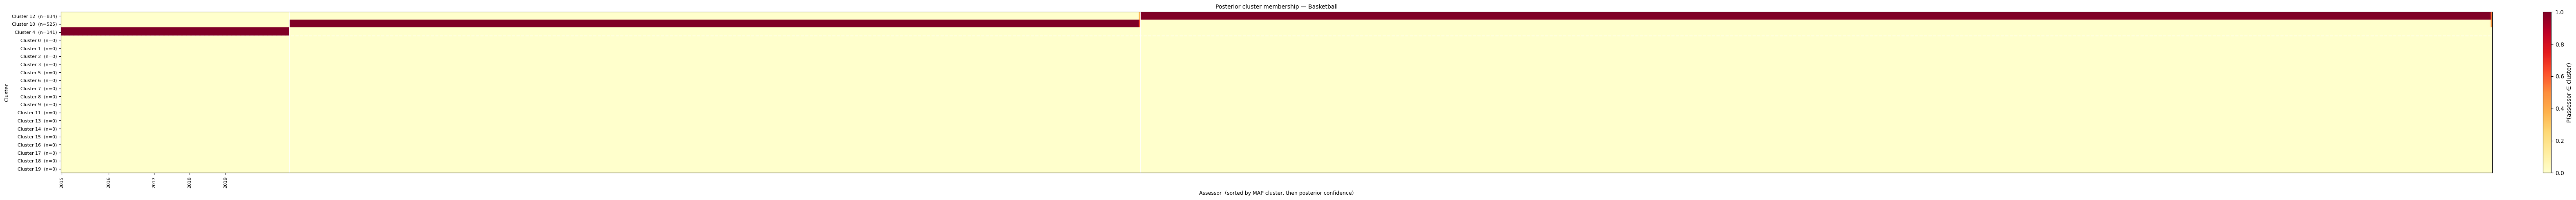

In [56]:
# ── Posterior membership heatmap — Basketball ─────────────────────────────────
z_arr_bk   = np.array(samples_bk.z_samples, dtype=np.intp)
T_samp_bk  = z_arr_bk.shape[0]
N_bk = len(rankings_list_bk)

membership_bk = np.zeros((N_bk, C_bk), dtype=np.float32)
for t in range(T_samp_bk):
    membership_bk[np.arange(N_bk), z_arr_bk[t]] += 1
membership_bk /= T_samp_bk

z_map_arr_bk  = np.array(map_result_bk["z"], dtype=int)
confidence_bk = membership_bk[np.arange(N_bk), z_map_arr_bk]

sort_ord_bk   = np.lexsort((-confidence_bk, z_map_arr_bk))
boundaries_bk = np.where(np.diff(z_map_arr_bk[sort_ord_bk]))[0]

cluster_sizes_bk = np.array([(z_map_arr_bk == c).sum() for c in range(C_bk)])
active_bk = [c for c in np.argsort(-cluster_sizes_bk) if cluster_sizes_bk[c] > 0]
inactive_bk = [c for c in range(C_bk) if cluster_sizes_bk[c] == 0]
row_order_bk = active_bk + inactive_bk

mem_display_bk = membership_bk[sort_ord_bk][:, row_order_bk]

season_x_bk = {}
for i_s, i_o in enumerate(sort_ord_bk):
    s = season_labels_bk[i_o]
    if s not in season_x_bk:
        season_x_bk[s] = i_s

fig, ax = plt.subplots(figsize=(max(12, N_bk * 0.04 + 4), max(5, len(active_bk) * 0.45 + 2)))
im = ax.imshow(mem_display_bk.T, vmin=0, vmax=1, cmap="YlOrRd", aspect="auto", interpolation="nearest")
for b in boundaries_bk:
    ax.axvline(b + 0.5, color="white", lw=0.9, alpha=0.9)
if inactive_bk:
    ax.axhline(len(active_bk) - 0.5, color="white", lw=1.5, linestyle="--", alpha=0.7)
ax.set_yticks(range(len(row_order_bk)))
ax.set_yticklabels([f"Cluster {c}  (n={cluster_sizes_bk[c]})" for c in row_order_bk], fontsize=8)
sorted_seasons_bk = sorted(season_x_bk.keys())
ax.set_xticks([season_x_bk[s] for s in sorted_seasons_bk])
ax.set_xticklabels(sorted_seasons_bk, rotation=90, fontsize=8)
ax.set_xlabel("Assessor  (sorted by MAP cluster, then posterior confidence)", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)
ax.set_title("Posterior cluster membership — Basketball", fontsize=10)
plt.colorbar(im, ax=ax, label="P(assessor ∈ cluster)", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

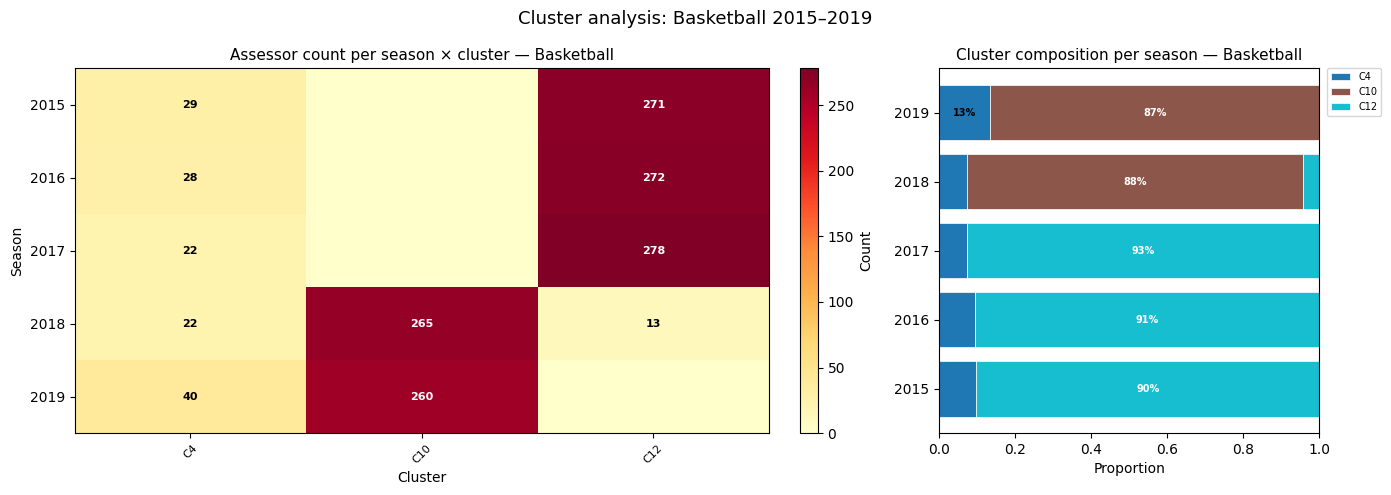

In [57]:
# ── Cluster analysis 2-panel — Basketball ─────────────────────────────────────
z_map_bk = np.array(map_result_bk["z"], dtype=int)
assess_df_bk = pd.DataFrame({"season": season_labels_bk, "cluster": z_map_bk})
active_bk2 = sorted(assess_df_bk["cluster"].unique())
n_active_bk = len(active_bk2)

cmap_bk = plt.get_cmap("tab20" if n_active_bk > 10 else "tab10", max(n_active_bk, 1))
cl_color_bk = {c: cmap_bk(i / max(n_active_bk - 1, 1)) for i, c in enumerate(active_bk2)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[2, 1])
ct_bk = pd.crosstab(assess_df_bk["season"], assess_df_bk["cluster"])
for c in active_bk2:
    if c not in ct_bk.columns:
        ct_bk[c] = 0
ct_bk = ct_bk[active_bk2]

im = ax1.imshow(ct_bk.values, cmap="YlOrRd", aspect="auto", interpolation="nearest")
ax1.set_xticks(range(len(active_bk2)))
ax1.set_xticklabels([f"C{c}" for c in active_bk2], fontsize=8, rotation=45)
ax1.set_yticks(range(len(ct_bk.index)))
ax1.set_yticklabels(ct_bk.index, fontsize=10)
ax1.set_xlabel("Cluster"); ax1.set_ylabel("Season")
ax1.set_title("Assessor count per season × cluster — Basketball", fontsize=11)
for i in range(ct_bk.shape[0]):
    for j in range(ct_bk.shape[1]):
        val = ct_bk.values[i, j]
        if val > 0:
            color = "white" if val > ct_bk.values.max() * 0.6 else "black"
            ax1.text(j, i, str(val), ha="center", va="center", fontsize=8, fontweight="bold", color=color)
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="Count")

ct_prop_bk = ct_bk.div(ct_bk.sum(axis=1), axis=0)
bottom_bk = np.zeros(len(ct_prop_bk))
for j, c in enumerate(active_bk2):
    vals = ct_prop_bk[c].values
    ax2.barh(range(len(ct_prop_bk)), vals, left=bottom_bk, color=cl_color_bk[c], label=f"C{c}", edgecolor="white", linewidth=0.5)
    for i, v in enumerate(vals):
        if v > 0.10:
            ax2.text(bottom_bk[i] + v / 2, i, f"{v:.0%}", ha="center", va="center", fontsize=7, fontweight="bold", color="white" if v > 0.25 else "black")
    bottom_bk += vals
ax2.set_yticks(range(len(ct_prop_bk)))
ax2.set_yticklabels(ct_prop_bk.index, fontsize=10)
ax2.set_xlabel("Proportion"); ax2.set_title("Cluster composition per season — Basketball", fontsize=11)
ax2.set_xlim(0, 1)
ax2.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0), ncol=1 if n_active_bk <= 10 else 2, borderaxespad=0, frameon=True)
fig.suptitle(f"Cluster analysis: {SPORT_BK} {min(YEARS_BK)}–{max(YEARS_BK)}", fontsize=13)
fig.tight_layout()
plt.show()

Dominant cluster per season:
  2015: Cluster 12  (271/300 = 90%)
  2016: Cluster 12  (272/300 = 91%)
  2017: Cluster 12  (278/300 = 93%)
  2018: Cluster 10  (265/300 = 88%)
  2019: Cluster 10  (260/300 = 87%)


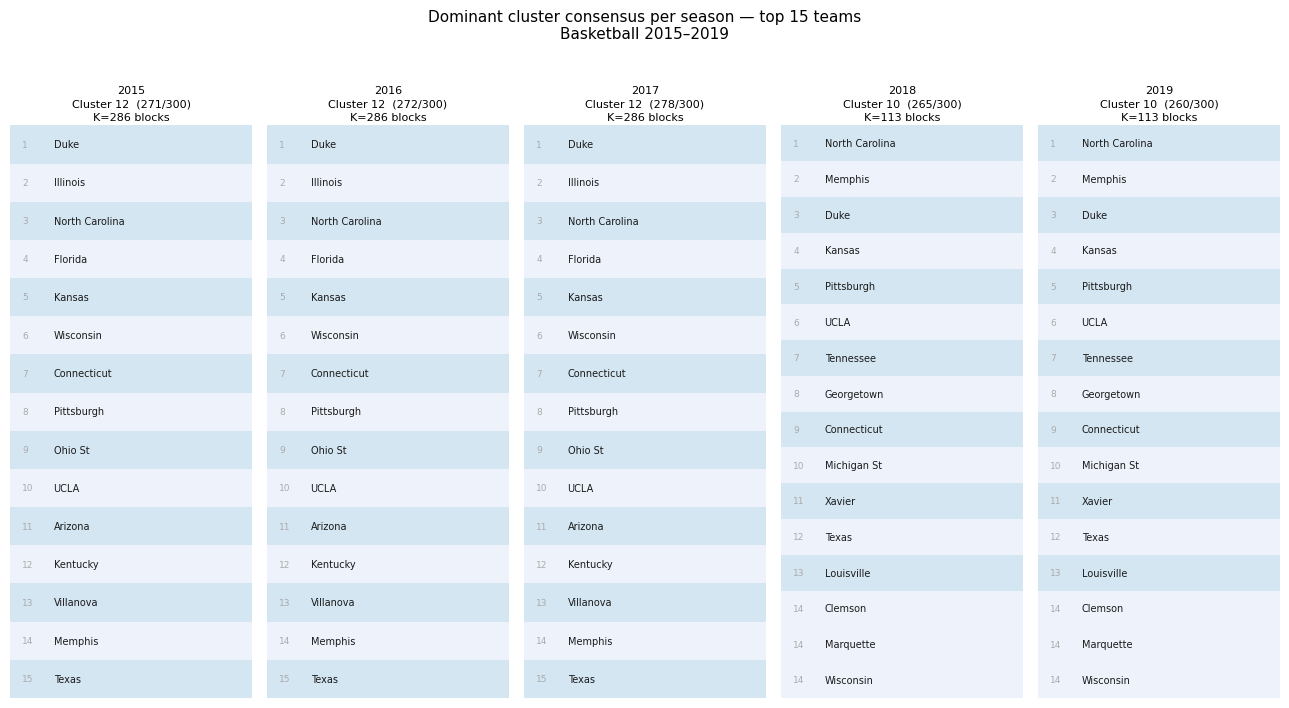

In [58]:
# ── Dominant cluster consensus per season — Basketball ────────────────────────
TOP_K_BK = 15
z_map_bk = np.array(map_result_bk["z"], dtype=int)
all_seasons_bk = sorted(set(season_labels_bk.tolist()))

dominant_bk = {}
for season in all_seasons_bk:
    mask = season_labels_bk == season
    counts = np.bincount(z_map_bk[mask], minlength=C_bk)
    dominant_bk[season] = int(np.argmax(counts))

season_cluster_order_bk = [dominant_bk[s] for s in all_seasons_bk]
print("Dominant cluster per season:")
for s, c in zip(all_seasons_bk, season_cluster_order_bk):
    n_total = (season_labels_bk == s).sum()
    n_dom   = (z_map_bk[season_labels_bk == s] == c).sum()
    print(f"  {s}: Cluster {c}  ({n_dom}/{n_total} = {n_dom/n_total:.0%})")

def top_k_from_blocks_bk(blocks, k):
    rows, pos = [], 1
    for b_idx, block in enumerate(blocks):
        for item_idx in block:
            name = team_names_bk[item_idx] if item_idx < len(team_names_bk) else f"Team {item_idx}"
            rows.append((pos, b_idx, name))
        pos += len(block)
        if pos > k:
            break
    return [r for r in rows if r[0] <= k]

ncols_bk = len(all_seasons_bk)
block_bg = ["#eef3fb", "#d4e6f2"]
fig, axes = plt.subplots(1, ncols_bk, figsize=(ncols_bk * 2.6, TOP_K_BK * 0.38 + 1.2), squeeze=False)

for col, (season, c) in enumerate(zip(all_seasons_bk, season_cluster_order_bk)):
    blocks = map_result_bk["clusters"][c]["blocks"]
    top_rows = top_k_from_blocks_bk(blocks, TOP_K_BK)
    n_blk = len(blocks)
    n_total = int((season_labels_bk == season).sum())
    n_dom = int((z_map_bk[season_labels_bk == season] == c).sum())

    ax = axes[0, col]
    ax.set_xlim(0, 1); ax.set_ylim(0, max(len(top_rows), 1)); ax.invert_yaxis(); ax.axis("off")
    ax.set_title(f"{season}\nCluster {c}  ({n_dom}/{n_total})\nK={n_blk} blocks", fontsize=8, pad=4, linespacing=1.4)

    prev_block, toggle = -1, 0
    for row_i, (rank_pos, b_idx, name) in enumerate(top_rows):
        if b_idx != prev_block:
            toggle, prev_block = 1 - toggle, b_idx
        ax.add_patch(plt.Rectangle((0, row_i), 1, 1, facecolor=block_bg[toggle], edgecolor="none", zorder=1))
        ax.text(0.05, row_i + 0.5, str(rank_pos), fontsize=6.5, va="center", ha="left", color="#aaaaaa", zorder=2)
        short = name if len(name) <= 22 else name[:21] + "…"
        ax.text(0.18, row_i + 0.5, short, fontsize=7, va="center", ha="left", color="#1a1a1a", zorder=2)

fig.suptitle(f"Dominant cluster consensus per season — top {TOP_K_BK} teams\n{SPORT_BK} {min(all_seasons_bk)}–{max(all_seasons_bk)}", fontsize=11, y=1.02)
fig.subplots_adjust(wspace=0.08)
plt.tight_layout()
plt.show()